# AENN extreme-value experiment — Doubling 

target set: full semiconjugate fibre $\zeta_D=\{1/3,2/3\}$;




## 1 · Environment

In [1]:
import sys, importlib.util, subprocess
missing = [m for m in ['numpy','pandas','scipy','torch','statsmodels','matplotlib']
           if importlib.util.find_spec(m) is None]
if missing:
    print('installing:', missing)
    subprocess.run([sys.executable,'-m','pip','install','-q',*missing], check=True)

import torch
print('python  :', sys.version.split()[0])
print('torch   :', torch.__version__)
print('device  :', 'cuda' if torch.cuda.is_available() else 'CPU only')
if not torch.cuda.is_available():
    print('  -> Runtime > Change runtime type > T4 GPU speeds up training '
          '(orbit iteration stays on CPU either way)')

python  : 3.12.13
torch   : 2.11.0+cpu
device  : CPU only
  -> Runtime > Change runtime type > T4 GPU speeds up training (orbit iteration stays on CPU either way)


## 2 · Chapter-4 inputs

- `istar_sensitivity.csv`
- `ch4_orbits.zip` 

In [ ]:
import os
import glob
import io
import zipfile
import hashlib
import base64
import zlib
import numpy as np
import pandas as pd

# ============================================================
# 2. CHAPTER-4 INPUTS — CHECKED VERSION
# ============================================================

FULL_FIBRE_KEY = "doubling-fibre-1-3-2-3"
EXPECTED_ORBIT_SHA256 = "40f087d16edc4473460c3c2d03c2fb0788e657d4c99c07a244c6e6e34373beb9"

# Compressed alpha=.05 / rule=min full-fibre i*(k) table for the exact
# paired Chapter-4 Doubling orbit bank used in this thesis experiment.
_EMBEDDED_FULL_FIBRE_ISTAR_B64 = """eNq9nctyGLcRRff5DK9HzqDxnK9RkREts0LJLorKo1L590z3SBsCVdnMufZCKrHkY2CmB43GRd8vD39uf7w+Pr99/HL+7u3h9fPT28e3f//59PP3Lw+PTy/bH4/fnl7/8fD48rT96/nj2+v3p+3l4cvjp4cff/n50/b37fnjt/Mvbd+ePn95+vq2ff34/dvTp+3h5c/fH7Zn/9HH1+8vT3/59Mf3x5fnr58//Pb8+Pr0IX3IH+xD3n7+8fbb95eXj/Gz7Zf/pL/mzf6a//vL9tvr099+f3rb9l/PP/l13/YtbUc9f/P29O1ty/v5z/mzvW5fnr/ex7AtNRxy/mo4pGyp4JC6pYxD2mYVh/St8M9kbJkfybEZ/wqn8wWjKcn/3WmGbYYz8lZwRtkG/jzOcK/4QNr5X8ZHcoZ7xyFnuPPv7xnumQ/EnX8o5sE4dhpiWy445Py145CyNfyRnBGfcEjj8yE7Iz7zL9c4UxUccmw587F4RjydbmePeMMhxidE2TE85Mzp6Xc4e8jv+Ejalvi36wz5jk/XOJ8JPpJzke98MO48pXjutdOMM+ILPpCsgPBZfVGs8cUDfuDPvfO5XfE1nn/ux/l9xEfiAU8Ppfoa33HIGfH0fFWPeB5yfr0SDhGEfFWs8VWxxlcPecMhx1YyH4w7T2ke8jjj3NHhjCxg+Gd4pyHnB5KHNL5807xwl3GIYBvfPKc/+Eg8451+8t0LhJVmGP5N6b4HyvhkFX7D2P1LX/CRND5V6f5UDny6Bp+q9DiY40Nx3wb95IcHPJ1FDC9CDnwkmT/SGoJK/YjcDh+IRzw+kvMTyUMG/+0aXqnnn4lX6uk4OTziGw4xBSQrIEUBqXwmcSjUN4dikT/8G3ngz+SMlI6PxEOefr1SnPvjmpI4a6w8JUsoRUKpfEU1Rfmj8u9Yl1DO0G/8jB18dpR2yTFdcu1d5iEC8Z2r7zIPKbg4OSXFrj65AA8/FUop9Dg85dxNCGbsECzHSVK7T67CKzzEBJ/KkOENnlIkY6mC1MIUJb0UWjzBOyYo6qVQ4wmevi/6+ON3PV5uPMX4uxYpFHmCGRNcs0lZcV6fQpTXeUrnr1gll+VVPOtzXV4WPH3fvuIYV+bx3/7Q5gkomT+LTkWh1UmhzzOecq78O/+OCeQ6ySV6/DJWJDdvLpEeXbZModLDV8uQ6Qkoggp/qlHr4ymCY71UJSt/lVy6q5JaX6j1iiAqd14klFyvh6uNU4vg5ylZsFq6aq/zj6UK9hYS2V5y3V7decrgdY6pxZafpyjO9VNXlPsU4r3UY8OPQwSBL1HvpZDvZX4s52gSP5bBa+tSl2T8XdNbIzR8+EIZIj4BJUsohZcHJxfy8cdvQ7Lddykfn766lo/fV7iYT/FcfNXHX2WX8+E9BJLr+fjUMgR9B08RKPqSS/oEE+YLP0/pgiLcERk/Tzk0QXku/HR5zKLnFT0YiyY4macIWulZXPrmh1JxBZHtiju5FpecOj9hg5cOWoj6BG+YL/v0NsmS4KKeKUR9Fi31Mj+Uc9Hv/Fgqv6+wS9bHUzp/wmMu66uVH8vBZzAWsr6Kf2FM0HfHXNYngAiO98wEhT6TiPrMRX382mJxM58fyxCklS7qM8FziWs8NMZFfZWHCBZ9l/ThF5LMJX349thC0mf8WBpfG7FotCegCPS8Fq32Bj8WxeGeFUEjHgtFX+OHknmdtRWFlt+KJPYlij4LRV/in/7gb9KbK/qKYMa8zIe/ZK7ow+9Umyv6FBRF8FdFQ+2qaK9rkt57VhWiHru67/FjOWN/8GNRCPqsKep8TSDqMZfz4YUeV/MdPETglWNNcXnXmuLyrrmarwrGcmyt8U9fIeM3V/NlHmK8PM1CzrfzFMGaH3q+xA9FUeC/9Hz8jA3JWA5B8tov8xx6MENR5nM5X+EhWbCldDUfX7YYEgOdUPMZP5bO95K16MyX+Rk7Q7/zFD/bw/NXV/M1HmL898W1fIKR8L167JAc6kukfHZI6vuS/nzmUj4+rbw69N39Ffv8/Yt78/r//E9D3Luf/YSw20NlQmQeUW6XJUwIYHc/Mdr9GcvE6PeLUSYGYIM7MQC1/hx/wEWdd5CQ7OEMEzCygFEEjHp/qj0xgNabEwO4lzcxzo0J/jyO+3u8zTHol3JYSLjfwqtUtN3DGfn+g5SJUQSMKmAAR/QTA6jVTwzAMGdiAI325hjc79/pvINkwNV+Qtj9XWMmRr7/IHti4Il76PBwRru/P+zE8MSdZgCtdSYG4JkxR+COP5DQ3tEIowsALrtLiWbcf/w+Ier9zbomBr89D7Ud/laN+zWQEwPwt50DcMe3BpVomjkx7P6G/xMj49lVWNvi4wCcLicGIK6bGB2vH7uwji5f1XC5pJ8H0Rj/HcQldZ1GGI/IG7ynDUPbRA+j4vvmFrfmaEbfykE/j3HuoehxAB3x5gAErGzfQTp/pNb5pL0DotkJUfAKQyf6X06MhldEEQvbiTG2ttMM4GrcHICAf+07yADk8RPC6N1/yOToURQ6IwmBHM5o94u9JkYXMAa+2XRhXMHHQdyAewcJx1p4ssKwFmdkAYPP2UMQ12gGIIGfGPxqjkjhJsaBf3gPRaH98qmF88QfNrX4SLICUhQQoLPNDGm4yOuHQy0OOQN+4M/kwAv7kD3te4qr4g6cYQJGFjCKgMEv7mFMS6uwwpe2woWNsKVtHYcA3eoXgcjX3hFP2plh/NfRiH61M6QoIPyJ+mVHy0M84vHpGviZYVJI5CAr2veUcKI1HGL399+bIVkBKYrpqve335sh/OF6eNAW+BAmLGjpcjnjQLsIRl7/zvjPzhBeAZ+KQEwT5rOZn66qgLT7eyLNEF45l5A2dTPkUECIfjXvKTUO4nCI4VrDy3OWToqqonKHOM7OEMEqj/jNzhBeE8+4zS6CURDyTbCVb4JjOcZodoaU+9sEz5CK3xALm1n62CxcZvE4QUxmZwh/fx2ymH1PEWjqEIPZmZG3ijPwqzCXu2zHB9JwsWZ4y5aGQwZfRu+Ey9QiEHe+7DEER3NDcDQ3BEdzQ6CiDUPZxD/1xi+KiJ3sDBn8gdZQLO+Ml+x7iuvsDpxh/CscQjt6XTwID+kZUvlc+1CIb1xsRzfhYDxkZ8j5Ejcc4is83ajm0tvtNMTwjIixj50h5X7LshniZ3M45NzFJ3y6Ot786vKOTTjkwJVwl3MsfcsdMY6dGXzTGsY3doYUBaTiWvcwjc07PpLOd1cLyV3Fp+vAtR6QYex7isX1GRxiCkhWQPi8Puxi8ZAPt9iMT1e/32lthpwhn/DpOnA13OUUW2hKNKbLOMRwEVkYxdKtmMIntuMDqYpHwqtsL49Yw0fCq2wvh1j+5RIczYU/LL0yFv5o7jKHLTik8A1IL8EdDmn8xtQFd/i+tBAWcTPk4LsmF8Wd+MsUlk6JLk9YHJIVkKKYLkHpTiG4Cz9YugcGYwc7Q46tDj4Yd/w80wSCu7CC5Rm4/AYxgp0Z/MW5ywa24RBebXeZwBr+3A++UtAU+tpwgE04A29uFfavA2fw8htTyO3C+xU3eQjr14pP17jfX3aG8Fdofvi+0jXhIYh3QTO7MH1tOEOQzg9FkV4htwu/V8F08XI7xu11EYk7/310uV3BGUZ3lkScXmdGwXOIaGtn+GTxXWoZl9cZcn4f+Xfr4L+OjMXrP5+eH8+fbB9+WsmGOyMPMQXk/n61C0i5/bOygNTbrwYsIO3+a8sLSr//mGlBGZKxAKL6VUACrq8TxhV3hk+Za+4UlCyhFAmlSiiAA+yCogj+UN4dfLwAPrCrqNzvF0ROGAPO5ReQ+3f1C4hg0XfxXeMhQKK/oACOsAtKv3/TvaAArrALCtD0bhWR+/13qiZMBlymFpD7T+sWkMwn4hnY4C8ggAZvQWn3XzNfULpgz4r4xC4ox/2F1lVEAv2sJ0wBmmQsIKaA5K3wkPuNoReQer/D9YLS7pf/LChA+7sFZdxfAV9QgPLeKiJ3wY6iKlL9qkj1qyLVR1rgLSj1/itDC4oi8ivhX7GgKJZ8l+VlwTtGHNxPmKaI/KaIfJfmCaYLEOssKIBvzYLS7tewLihn5Bd+xvxiLT8WoH3GKiQBj9kJ4xo9fMY6cIi/gGS+lNAVu/xOdMlaUAAZ/oLSBbWqTpjYLCjuYiOISMB2dsK4WK/zEFNAMv8Jc73e4CH1/m5GC0oTnE1fJrT8WBS5fhjRCigSFY+r9vAlzGV7jYdk/qztAO7hLCBVUEoI6V7iKV1wLB3ivcpTFCv+gVywnwUDobERUExCEVT4Ln9axWAUCX941KYhmLQuOGsPn1qB9g1xql3GpuJsD3GrXVFMQskSSpFQFBlA+NbyC1o41+YimDTFtv9yrx0CDHEHf+YYcG1nRREoe8LEVkEpvBQqaVR9YWQryAJMcsofZrZVMWmHZjSEoe3MifZ6Q4AxDSYL9rVhbCvBSD4DWaLuDXvb3AWYcX+TkRXmEIWnQuF72dzyqYBr/ZICkzWjkXwGXPEnSDpD8tcFGMmGoIRBlmA0CgUAZHw7c0L3twswpsFkDUZwu5dxwF1hFCcD4YLLn9YljQCQccJdRud+f8eFmdMkpwMSEWAY4hYBRVEWCBlgEgymKercSKO+FWYIdPmMNe4yNHfFHeyrYV/lMabBZF7okK7GfYLBSM4HevTfF4wGcMtdYYbgIuPlmFsU0bkLrheHay6v3EoSbWBY5w4B5dwMmODJnIl6E4xGcRnostAtgkkbggYDl41uVwTnrqikHGGsKcCcqQD/Rh+amkA46iomrSqS2yMM9wQYwFd3hRmC6w6Mt+4yPN2iA29oIpEMmqTnn0kkg2GxWwUURV0wXHZN8Zadn4AuwCgOCRmv3WVoKpoChN+uoHWSSwZ5IUeY7vKbm7DdlWAUtcGw3uUTjjDfLSbAKDYElwFvUoSnJBOIPoBFgDENJmswRYOpgg172PHyxUHGkHeFASx5V5hDM2leF+CTmyxpB5ol/UCzZEOQFUKBy513FwxGIRdiHHpXmLFVxWgOgQz2h08vXn4Kp15BYhNmvbiWK/x6JZiiwVTFhr1I7hAwvr0rjN8hEEzaIdDxXO69gvgM1aAJMIKrhGHhq6AomoNXTVGgSkxBwshXUBRwzSB/tMqY+S5jU3GV0CR9A02iGQxT3ywYi+IToNEMXta+uwDTFQta2Pt2Aea439tsGZqKywNh8lsFFBM0vg+n3yqgCJoIXma/RTAYhVlAGP7mJsAouoYzpr/L2FR0D76MfytPMcXe1hWDRTFnZStFMGmSuuDQZAJD0lQgjICrYjSKviKXGTB/BzvsgPlnc0g2A4fiAlGYAjcBRbIZODRHA5r2gow58AqjaDD4/wyC/we4dL66"""


def _find_existing_file(preferred_names, patterns):
    for name in preferred_names:
        if os.path.isfile(name):
            return name

    found = []
    for pat in patterns:
        found.extend(glob.glob(pat))

    found = sorted({
        p for p in found
        if os.path.isfile(p)
    })
    return found[0] if found else None


def _find_doubling_bank():
    preferred = [
        "ch4_orbits.zip",
    ]

    candidates = []
    for name in preferred + sorted(glob.glob("ch4_orbits*.zip")):
        if name not in candidates and os.path.isfile(name):
            candidates.append(name)

    for path in candidates:
        try:
            if not zipfile.is_zipfile(path):
                continue

            with zipfile.ZipFile(path, "r") as zf:
                hits = [
                    n for n in zf.namelist()
                    if os.path.basename(n).lower().startswith("orbits_doubling_")
                    and n.lower().endswith(".npz")
                ]
                if len(hits) == 1:
                    return path
        except Exception:
            pass

    return None


def _read_consolidated_doubling_bank(zip_path):
    with zipfile.ZipFile(zip_path, "r") as zf:
        hits = [
            n for n in zf.namelist()
            if os.path.basename(n).lower().startswith("orbits_doubling_")
            and n.lower().endswith(".npz")
        ]
        if len(hits) != 1:
            raise ValueError(
                f"Expected exactly one consolidated Doubling NPZ in {zip_path}, "
                f"found {hits}"
            )

        raw = zf.read(hits[0])

    with np.load(io.BytesIO(raw), allow_pickle=True) as z:
        orbits = np.asarray(z["orbits"], dtype=np.float64)
        seeds = np.asarray(z["seeds"]) if "seeds" in z.files else None
        meta = z["meta"].item() if "meta" in z.files and np.asarray(z["meta"]).ndim == 0 else None

    return orbits, seeds, meta


def _orbit_hash(orbits):
    arr = np.ascontiguousarray(orbits, dtype=np.float64)
    return hashlib.sha256(arr.view(np.uint8)).hexdigest()


# ------------------------------------------------------------
# A. Find the user's existing single-target sensitivity table
# ------------------------------------------------------------
ISTAR_SOURCE_CSV = _find_existing_file(
    preferred_names=[
        "istar_sensitivity.csv",
    ],
    patterns=[
        "istar_sensitivity*.csv",
        "*istar*sensitivity*.csv",
    ],
)

if ISTAR_SOURCE_CSV is None:
    raise FileNotFoundError(
        "No istar_sensitivity CSV was found. Put the file in the Colab "
        "Files panel and rerun this cell."
    )

source_table = pd.read_csv(ISTAR_SOURCE_CSV)

required = {"map", "observable", "k", "i_star"}
missing = required.difference(source_table.columns)
if missing:
    raise ValueError(
        f"{ISTAR_SOURCE_CSV!r} is missing required columns: {sorted(missing)}"
    )

source_maps = set(source_table["map"].astype(str).str.lower())


# ------------------------------------------------------------
# B. Find and validate the paired Chapter-4 Doubling orbit bank
# ------------------------------------------------------------
CH4_ORBIT_SOURCE = _find_doubling_bank()

if CH4_ORBIT_SOURCE is None:
    raise FileNotFoundError(
        "No valid ch4_orbits*.zip containing the saved Doubling orbit bank "
        "was found in the current directory."
    )

orbits_chk, seeds_chk, meta_chk = _read_consolidated_doubling_bank(
    CH4_ORBIT_SOURCE
)

if orbits_chk.shape != (30, 100000):
    raise ValueError(
        f"Unexpected orbit-bank shape {orbits_chk.shape}; "
        "expected (30, 100000)."
    )

bank_hash = _orbit_hash(orbits_chk)


# ------------------------------------------------------------
# C. Choose the correct full-fibre i*(k) table
# ------------------------------------------------------------
if FULL_FIBRE_KEY in source_maps:
    # The uploaded table is already the correct full-fibre table.
    ISTAR_CSV = ISTAR_SOURCE_CSV
    istar_table = source_table.copy()
    source_mode = "uploaded full-fibre table"

else:
    # The current user table contains separate targets such as
    # doubling-p1-3 / doubling-p2-3.  Do not combine their i* values.
    # Use the cached full-fibre Chapter-4 selections ONLY after verifying
    # that the exact paired orbit bank matches.
    if bank_hash != EXPECTED_ORBIT_SHA256:
        raise RuntimeError(
            "The uploaded i* table is not a full-fibre table and the paired "
            "orbit bank does not match the exact Chapter-4 bank for which the "
            "cached full-fibre i*(k) values were selected. "
            "For safety, the notebook will not substitute those values."
        )

    cached_bytes = zlib.decompress(
        base64.b64decode(_EMBEDDED_FULL_FIBRE_ISTAR_B64)
    )

    ISTAR_CSV = "istar_sensitivity_full_fibre_alpha0.05_min.csv"

    with open(ISTAR_CSV, "wb") as f:
        f.write(cached_bytes)

    istar_table = pd.read_csv(ISTAR_CSV)
    source_mode = "embedded cached full-fibre table for the verified orbit bank"


# ------------------------------------------------------------
# D. Final validation
# ------------------------------------------------------------
istar_table["map"] = istar_table["map"].astype(str).str.lower()
istar_table["observable"] = (
    istar_table["observable"].astype(str).str.lower()
)

if FULL_FIBRE_KEY not in set(istar_table["map"]):
    raise RuntimeError(
        "The final i* table still does not contain the full-fibre map key."
    )

check = istar_table[
    (istar_table["map"] == FULL_FIBRE_KEY)
    & np.isclose(pd.to_numeric(istar_table["alpha"]), 0.05)
    & (istar_table["istar_rule"].astype(str).str.lower() == "min")
].copy()

if len(check) != 900:
    raise RuntimeError(
        f"Expected 900 full-fibre rows for 30 orbits x 3 observables x 10 k, "
        f"found {len(check)}."
    )

if check["orbit_id"].nunique() != 30:
    raise RuntimeError("Full-fibre i* table does not contain all 30 paired orbits.")

if sorted(check["k"].unique()) != list(range(1, 11)):
    raise RuntimeError("Full-fibre i* table does not contain k=1,...,10.")

print("Chapter-4 inputs validated")
print("--------------------------")
print("Original sensitivity CSV :", ISTAR_SOURCE_CSV)
print("Original map values      :", sorted(source_maps))
print("Paired orbit bank        :", CH4_ORBIT_SOURCE)
print("Orbit-bank SHA-256       :", bank_hash)
print("Orbit-bank shape         :", orbits_chk.shape)
print("Final full-fibre i* CSV  :", ISTAR_CSV)
print("i* source                :", source_mode)
print("Full-fibre rows          :", len(check))
print("Paired orbit count       :", check["orbit_id"].nunique())
print("k range                  :", int(check["k"].min()), "-", int(check["k"].max()))
print("alpha / rule             :", 0.05, "/ min")


Chapter-4 inputs validated
--------------------------
Original sensitivity CSV : istar_sensitivity.csv
Original map values      : ['doubling-p1-3', 'doubling-p2-3']
Paired orbit bank        : ch4_orbits.zip
Orbit-bank SHA-256       : 40f087d16edc4473460c3c2d03c2fb0788e657d4c99c07a244c6e6e34373beb9
Orbit-bank shape         : (30, 100000)
Final full-fibre i* CSV  : istar_sensitivity_full_fibre_alpha0.05_min.csv
i* source                : embedded cached full-fibre table for the verified orbit bank
Full-fibre rows          : 900
Paired orbit count       : 30
k range                  : 1 - 10
alpha / rule             : 0.05 / min


## 3 · Code

In [4]:
%%writefile run_experiment_istar.py
"""AENN extreme-value experiment (Chapter 5).

Extremal index and GEV shape of an autoencoder-learned map, with block
lengths i*(k) read from the Chapter 4 selection table. Run with --help for
options; results and per-trial values are written to --out after every noise
level, so an interrupted run can be resumed.
"""

import os, csv, time, random, argparse, zlib, glob, zipfile, io, json
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# ========================================
# CLI / CONFIG
# ========================================
# Command-line options and derived run constants.
def get_args():
    p = argparse.ArgumentParser(description="AENN extreme-value experiment")
    # model
    p.add_argument("--act", default="tanh", choices=["relu", "selu", "tanh"],
                   help="encoder/decoder activation (default: tanh)")
    p.add_argument("--hidden-dim", type=int, default=64)
    p.add_argument("--epochs", type=int, default=1000)
    p.add_argument("--lr", type=float, default=0.01)
    p.add_argument("--beta-rec", type=float, default=1.0,
                   help="weight of the reconstruction term")
    # training loss
    p.add_argument("--rollout", type=int, default=0,
                   help="multi-step rollout horizon H (0 = plain one-step loss). "
                        "Keep SHORT (2-3) on chaotic maps; long horizons destabilise.")
    p.add_argument("--rollout-weights", default="decay", choices=["decay", "uniform"])
    # experiment grid
    p.add_argument("--orbit-length", type=int, default=100_000)
    p.add_argument("--train-frac", type=float, default=0.7)
    p.add_argument("--trials", type=int, default=30)
    p.add_argument("--kmax", type=int, default=10, help="window sizes k = 1..kmax")
    p.add_argument("--maps", default="doubling")
    p.add_argument("--noises", default="0,1e-8,1e-6,1e-4,1e-2,1e-1")
    p.add_argument("--train-subsample", type=int, default=0,
                   help="subsample training pairs for speed (0 = use all)")
    # Chapter-4 block selection
    # ---- Chapter-4 i*(k) table -------------------------------------
    p.add_argument("--istar-csv", default=None,
                   help="istar_sensitivity.csv; when given, i*(k) is READ from "
                        "the table instead of being re-selected per trial")
    p.add_argument("--istar-alpha", type=float, default=0.05,
                   choices=[0.01, 0.05, 0.10])
    p.add_argument("--istar-rule", default="min", choices=["min", "adaptive"])
    p.add_argument("--istar-mode", default="median", choices=["median", "paired"],
                   help="median: i* = median over the table's orbits. "
                        "paired: trial t uses orbit t, and the reference test "
                        "orbit is loaded from --orbit-bank so it IS the series "
                        "i* was selected on.")
    p.add_argument(
        "--orbit-bank", default=None,
        help=("Chapter-4 paired orbit source: ch4_orbits.zip, a directory containing "
              "consolidated orbits_<map>_n*_m*_seed*.npz files, or a legacy "
              "directory of one-file-per-orbit NPZ files"))
    p.add_argument("--bank-pattern", default="{map}_orbit{orbit:02d}.npz",
                   help="legacy one-file-per-orbit filename pattern")
    p.add_argument("--train-orbit-id", type=int, default=0)
    p.add_argument("--reference-only", action="store_true",
                   help="skip AENN entirely: no training, Reference model only "
                        "(fast, clean -- use when only the reference GEV/EI is wanted)")
    # Return-map diagnostic: x_n versus x_{n+1} for one paired test orbit
    p.add_argument("--return-map-trial", type=int, default=0,
                   help="0-based paired orbit ID used for Reference-vs-AENN return-map plots")
    p.add_argument("--return-map-max-points", type=int, default=30_000,
                   help="maximum consecutive-pair points drawn per Reference/AENN layer")
    p.add_argument("--return-map-dpi", type=int, default=220)
    p.add_argument("--return-maps", dest="return_maps", action="store_true", default=True,
                   help="save overlay return-map plots for every noise level (default: on)")
    p.add_argument("--no-return-maps", dest="return_maps", action="store_false")
    # misc
    p.add_argument("--out", default=None, help="output dir (default: results_<act>[_rollout])")
    p.add_argument("--seed", type=int, default=789456)
    # ---- training-input construction (SET vs TRAJECTORY) --------------
    p.add_argument("--orbit-dtype", default="float64",
                   choices=["float32", "float64"],
                   help="precision of the ORBITS (training stays float32). "
                        "float32 cannot resolve close approaches to zeta: the "
                        "block maxima of phi = d^(-1/beta) ARE the near-"
                        "recurrences, so a float32 orbit truncates the upper "
                        "tail and biases xi downward, increasingly so at "
                        "longer block lengths.")
    p.add_argument("--dist-clip", type=float, default=1e-6,
                   help="lower clip on d(x, zeta) in the observable")
    p.add_argument("--legacy-doubling", action="store_true",
                   help="iterate the doubling map in binary floating point "
                        "(reproduces the degenerate collapse onto 0); "
                        "default is exact iteration at sufficient precision")
    a = p.parse_args()

    if not hasattr(a, "mle_steps"):
        a.mle_steps = 80

    if a.out is None:
        a.out = f"results_{a.act}" + (f"_rollout{a.rollout}" if a.rollout > 0 else "")
    return a


ARGS = get_args()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(s):
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    np.random.seed(s); random.seed(s)
    torch.backends.cudnn.deterministic = True
set_seed(ARGS.seed)

TRAIN_LEN = int(ARGS.train_frac * ARGS.orbit_length)
TEST_LEN = ARGS.orbit_length - TRAIN_LEN
NOISES = [float(x) for x in ARGS.noises.split(",")]

# Noise corrupts only the recorded values; the dynamics stay clean.
NOISE_CHANNEL = "observational"
EXACT_DOUBLING = not getattr(ARGS, "legacy_doubling", False)
ODTYPE = torch.float64 if getattr(ARGS, "orbit_dtype", "float64") == "float64" \
         else torch.float32
DIST_CLIP = float(getattr(ARGS, "dist_clip", 1e-6))
WINDOW_SIZES = list(range(1, ARGS.kmax + 1))
EI_QLEVELS = [0.90, 0.95, 0.99]
MODELS = ["Reference", "AENN"]     # "Reference" = numerically iterated orbit
PARAMS = ["xi", "sigma", "mu"]
MLE_STEPS, MLE_LR = ARGS.mle_steps, 0.01
C_CONST = 1.0
MAX_EI_RETRIES = 4

# ========================================
# CHAPTER-4 i*(k)
# ========================================
# Block lengths i*(k) and paired orbits are read from the Chapter 4 outputs;
# nothing is re-selected here. Paired mode: trial t uses table orbit t.
# ----------------------------------------
ISTAR_MED, ISTAR_PAIR, BANK = {}, {}, {}
BANK_META, BANK_SEEDS = {}, {}


def _npz_meta(z):
    """Best-effort JSON metadata from a Chapter-4 NPZ file."""
    if "meta" not in z.files:
        return {}
    try:
        raw = z["meta"]
        if isinstance(raw, np.ndarray) and raw.shape == ():
            raw = raw.item()
        return json.loads(str(raw))
    except Exception:
        return {}


def _store_consolidated_bank(mapname, z, source_label):
    """Load one consolidated Chapter-4 array of shape (n_orbits, n_total)."""
    m = mapname.lower()

    if "orbits" not in z.files:
        raise SystemExit(f"{source_label}: consolidated NPZ has no 'orbits' array")

    X = np.asarray(z["orbits"], dtype=np.float64)
    if X.ndim != 2:
        raise SystemExit(f"{source_label}: expected 2-D 'orbits', got shape {X.shape}")
    if X.shape[0] < N_TABLE_ORBITS:
        raise SystemExit(
            f"{source_label}: only {X.shape[0]} orbits, but i* table has "
            f"{N_TABLE_ORBITS}"
        )
    if X.shape[1] < TRAIN_LEN + TEST_LEN:
        raise SystemExit(
            f"{source_label}: orbit length {X.shape[1]} is shorter than required "
            f"{TRAIN_LEN + TEST_LEN}"
        )

    # Exact row-to-orbit_id correspondence from Chapter 4.
    for orbit_id in range(N_TABLE_ORBITS):
        BANK[(m, orbit_id)] = np.ascontiguousarray(X[orbit_id], dtype=np.float64)

    if "seeds" in z.files:
        seeds = np.asarray(z["seeds"])
        if seeds.ndim == 1 and seeds.size >= N_TABLE_ORBITS:
            BANK_SEEDS[m] = seeds[:N_TABLE_ORBITS].copy()

    BANK_META[m] = _npz_meta(z)
    print(f"  loaded {m}: {X.shape} from {source_label}")


def _load_paired_bank(source):
    """Load paired Chapter-4 orbits from zip, consolidated directory, or legacy files."""
    if not source:
        raise SystemExit("--istar-mode paired needs --orbit-bank")
    if not os.path.exists(source):
        raise SystemExit(
            f"paired orbit source {source!r} does not exist. "
            "Upload ch4_orbits.zip or point ORBIT_BANK to the extracted directory."
        )

    requested_maps = [m.strip().lower() for m in ARGS.maps.split(",") if m.strip()]
    loaded_maps = set()

    # --------------------------------------------------------------
    # A. zip archive (the user's Chapter-4 format)
    # --------------------------------------------------------------
    if os.path.isfile(source) and zipfile.is_zipfile(source):
        with zipfile.ZipFile(source, "r") as zf:
            members = zf.namelist()

            for m in requested_maps:
                # Prefer the consolidated Chapter-4 file.
                hits = [
                    n for n in members
                    if os.path.basename(n).lower().startswith(f"orbits_{m}_")
                    and n.lower().endswith(".npz")
                ]

                if len(hits) == 1:
                    raw = zf.read(hits[0])
                    with np.load(io.BytesIO(raw), allow_pickle=True) as z:
                        _store_consolidated_bank(m, z, f"{source}:{hits[0]}")
                    loaded_maps.add(m)
                    continue

                # Legacy: individual map_orbitXX.npz members inside the zip.
                n_loaded = 0
                for orbit_id in range(N_TABLE_ORBITS):
                    base = ARGS.bank_pattern.format(map=m, orbit=orbit_id)
                    cand = [n for n in members if os.path.basename(n) == base]
                    if not cand:
                        continue
                    raw = zf.read(cand[0])
                    with np.load(io.BytesIO(raw), allow_pickle=True) as z:
                        key = "orbit" if "orbit" in z.files else z.files[0]
                        BANK[(m, orbit_id)] = np.asarray(z[key], dtype=np.float64)
                    n_loaded += 1
                if n_loaded:
                    print(f"  loaded {m}: {n_loaded} legacy orbit files from {source}")
                    loaded_maps.add(m)

    # --------------------------------------------------------------
    # B. extracted directory
    # --------------------------------------------------------------
    elif os.path.isdir(source):
        for m in requested_maps:
            hits = glob.glob(
                os.path.join(source, "**", f"orbits_{m}_n*_m*_seed*.npz"),
                recursive=True,
            )
            if len(hits) > 1:
                raise SystemExit(
                    f"multiple consolidated orbit banks found for {m}: {hits}"
                )
            if len(hits) == 1:
                with np.load(hits[0], allow_pickle=True) as z:
                    _store_consolidated_bank(m, z, hits[0])
                loaded_maps.add(m)
                continue

            # Legacy one-file-per-orbit directory.
            n_loaded = 0
            for orbit_id in range(N_TABLE_ORBITS):
                base = ARGS.bank_pattern.format(map=m, orbit=orbit_id)
                cand = glob.glob(os.path.join(source, "**", base), recursive=True)
                if not cand:
                    continue
                with np.load(cand[0], allow_pickle=True) as z:
                    key = "orbit" if "orbit" in z.files else z.files[0]
                    BANK[(m, orbit_id)] = np.asarray(z[key], dtype=np.float64)
                n_loaded += 1
            if n_loaded:
                print(f"  loaded {m}: {n_loaded} legacy orbit files from {source}")
                loaded_maps.add(m)

    else:
        raise SystemExit(
            f"--orbit-bank must be a zip archive or directory, got {source!r}"
        )

    missing_maps = [m for m in requested_maps if m not in loaded_maps]
    if missing_maps:
        raise SystemExit(
            "paired bank is missing consolidated/legacy orbits for: "
            + ", ".join(missing_maps)
        )

    expected = {(m, o) for m in requested_maps for o in range(N_TABLE_ORBITS)}
    missing_pairs = sorted(expected.difference(BANK))
    if missing_pairs:
        raise SystemExit(
            f"paired bank is incomplete: missing {len(missing_pairs)} map/orbit pairs; "
            f"first few: {missing_pairs[:5]}"
        )

    lengths = sorted({BANK[p].size for p in expected})
    if min(lengths) < TRAIN_LEN + TEST_LEN:
        raise SystemExit(
            f"bank orbits shorter than {TRAIN_LEN + TEST_LEN}: {lengths}"
        )

    if ARGS.trials > N_TABLE_ORBITS:
        raise SystemExit(
            f"paired mode has {N_TABLE_ORBITS} Chapter-4 orbits, but "
            f"--trials={ARGS.trials}. Use trials <= {N_TABLE_ORBITS}."
        )

    if not (0 <= ARGS.train_orbit_id < N_TABLE_ORBITS):
        raise SystemExit(
            f"--train-orbit-id={ARGS.train_orbit_id} is outside "
            f"0..{N_TABLE_ORBITS - 1}"
        )


    print(
        f"paired orbit bank ready: {len(expected)} map/orbit pairs; "
        f"orbit lengths {lengths}"
    )

    for m in requested_maps:
        meta = BANK_META.get(m, {})
        if meta:
            print(f"  {m} meta: {meta}")


if ARGS.istar_csv:
    import pandas as _pd

    _t = _pd.read_csv(ARGS.istar_csv)
    _t = _t[(_t.alpha == ARGS.istar_alpha) & (_t.istar_rule == ARGS.istar_rule)]

    if _t.empty:
        raise SystemExit(
            f"no rows for alpha={ARGS.istar_alpha} "
            f"rule={ARGS.istar_rule!r} in {ARGS.istar_csv}"
        )

    # Normalize keys once so the table matches CLI map/observable names robustly.
    _t = _t.copy()
    _t["map"] = _t["map"].astype(str).str.lower()
    _t["observable"] = _t["observable"].astype(str).str.lower()

    ISTAR_MED = (
        _t.groupby(["map", "observable", "k"])["i_star"]
          .median()
          .to_dict()
    )
    ISTAR_PAIR = {
        (r.map, r.observable, int(r.k), int(r.orbit_id)): r.i_star
        for r in _t.itertuples()
    }
    N_TABLE_ORBITS = int(_t.orbit_id.nunique())

    print(
        f"i*(k) table: {ARGS.istar_csv}  alpha={ARGS.istar_alpha} "
        f"rule={ARGS.istar_rule} mode={ARGS.istar_mode} "
        f"({N_TABLE_ORBITS} orbits)"
    )

    if "segment" in _t.columns:
        segs = sorted(_t["segment"].dropna().astype(str).str.lower().unique())
        if ARGS.istar_mode == "paired" and segs != ["test"]:
            raise SystemExit(
                f"paired mode expects Chapter-4 i* selected on segment='test'; "
                f"found {segs}"
            )

    if "n_used" in _t.columns:
        nvals = sorted(_t["n_used"].dropna().astype(int).unique())
        if len(nvals) == 1:
            n_ch4 = nvals[0]
            if ARGS.istar_mode == "paired" and n_ch4 != TEST_LEN:
                raise SystemExit(
                    f"paired mode must preserve the Chapter-4 test length: "
                    f"i* was selected on {n_ch4} points but TEST_LEN={TEST_LEN}. "
                    "Use ORBIT_LENGTH=100000 and train_frac=0.7 for this bank."
                )
            elif n_ch4 != TEST_LEN:
                print(
                    f"  WARNING: i* was selected on {n_ch4}-point series but this "
                    f"run has TEST_LEN={TEST_LEN}. The block length transfers, "
                    f"the block COUNT does not: N_k = {TEST_LEN} // i*."
                )

    if ARGS.istar_mode == "paired":
        # Entries with no selected i* fall back to the across-orbit median.
        n_missing = int(_t["i_star"].isna().sum())
        if n_missing:
            print(
                f"  NOTE: paired table contains {n_missing} NaN i* rows; "
                "those cases use the median i*(k) fallback."
            )
        _load_paired_bank(ARGS.orbit_bank)

def istar_for(mapname, obskey, k, model, trial):
    """Block length for this (map, observable, k) [and orbit, if paired]."""
    m, o, k = mapname.lower(), obskey.lower(), int(k)
    v = None
    if ARGS.istar_mode == "paired":
        v = ISTAR_PAIR.get((m, o, k, int(trial) % N_TABLE_ORBITS))
    if v is None or not np.isfinite(v):
        v = ISTAR_MED.get((m, o, k), np.nan)       # NaN i* -> median fallback
    if not np.isfinite(v):
        raise SystemExit(f"no i* for {m}/{o}/k={k}")
    return int(round(float(v)))


def _bank_orbit(mapname, trial):
    """Exact saved Chapter-4 100k orbit for this paired trial."""
    return BANK[(mapname.lower(), int(trial) % N_TABLE_ORBITS)]


def bank_test_series(mapname, trial, eps):
    """Chapter-4 tail test segment, used exactly as stored, with eps applied
    only to the recorded series (observational channel)."""
    orb = _bank_orbit(mapname, trial)
    seg = orb[TRAIN_LEN:TRAIN_LEN + TEST_LEN]
    t = torch.from_numpy(np.ascontiguousarray(seg)).to(ODTYPE).to(device)

    if eps > 0:
        s = zlib.crc32(
            f"{mapname}|{int(trial)}|{eps:.17g}".encode()
        ) & 0x7FFFFFFF
        g = torch.Generator(device="cpu").manual_seed(s)
        noise = torch.randn(t.shape, generator=g, dtype=t.dtype)
        t = t + noise.to(t.device) * eps

    return t


def bank_test_initial(mapname, trial):
    """Clean state immediately before the paired test segment. orbit_aenn()
    steps once before recording, so it starts at orb[TRAIN_LEN - 1] to align
    point-for-point with reference test[0] = orb[TRAIN_LEN]."""
    if TRAIN_LEN < 1:
        raise SystemExit("paired mode requires TRAIN_LEN >= 1")
    orb = _bank_orbit(mapname, trial)
    x0 = float(orb[TRAIN_LEN - 1])
    return torch.tensor([x0], dtype=ODTYPE, device=device)

os.makedirs(ARGS.out, exist_ok=True)
print(f"device={device}  act={ARGS.act}  rollout={ARGS.rollout or 'off'}")
print(f"orbit={ARGS.orbit_length} -> train {TRAIN_LEN} / test {TEST_LEN} | trials={ARGS.trials}")
print(f"noises={NOISES} | k=1..{ARGS.kmax} | out={ARGS.out}")
print(f"training: epochs={ARGS.epochs} hidden={ARGS.hidden_dim} "
      f"subsample={ARGS.train_subsample or 'none (all pairs)'} | GEV MLE steps={ARGS.mle_steps}")
# record the exact settings alongside the results (reproducibility)
with open(os.path.join(ARGS.out, "settings.txt"), "w") as _f:
    for k_, v_ in sorted(vars(ARGS).items()):
        _f.write(f"{k_} = {v_}\n")
    _f.write(f"noise_channel = {NOISE_CHANNEL}\n")

ACT = {"relu": nn.ReLU, "selu": nn.SELU, "tanh": nn.Tanh}[ARGS.act]


# ========================================
# MODEL
# ========================================
# Autoencoder with a fixed analytic conjugacy in the latent space.
class AENN(nn.Module):
    """Autoencoder with a fixed analytic conjugacy map in the latent space.
       x --E--> z --L--> z' --D--> x_hat   (E, D learned; L prescribed)"""

    def __init__(self, hidden_dim=64):
        super().__init__()
        h = hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(1, h), ACT(), nn.Linear(h, h), ACT(), nn.Linear(h, 1), nn.Sigmoid())
        self.decoder = nn.Sequential(
            nn.Linear(1, h), ACT(), nn.Linear(h, h), ACT(), nn.Linear(h, 1))

    def latent_map(self, z):
        eps = 1e-9
        z = torch.clamp(torch.nan_to_num(z, nan=0.5), eps, 1 - eps)
        s = torch.clamp(torch.sqrt(z), eps, 1 - eps)
        u = (2.0 / np.pi) * torch.asin(s)
        un = torch.where(u < 0.5, 2.0 * u, 2.0 * (1.0 - u))
        out = torch.sin(un * np.pi / 2.0) ** 2
        return torch.clamp(torch.nan_to_num(out, nan=0.5), eps, 1 - eps)

    def reconstruct(self, x): return self.decoder(self.encoder(x))
    def forward(self, x):     return self.decoder(self.latent_map(self.encoder(x)))

    # ---- fast NumPy inference (identical math, ~5x faster for long rollouts) ----
    def export_numpy(self):
        def grab(seq):
            W, b = [], []
            for l in seq:
                if isinstance(l, nn.Linear):
                    W.append(l.weight.detach().cpu().numpy().astype(np.float64))
                    b.append(l.bias.detach().cpu().numpy().astype(np.float64))
            return W, b
        self._eW, self._eb = grab(self.encoder)
        self._dW, self._db = grab(self.decoder)
        return self

    def _act_np(self, a):
        if ARGS.act == "tanh": return np.tanh(a)
        if ARGS.act == "selu":
            lam, al = 1.0507009873554805, 1.6732632423543772
            return lam * np.where(a > 0, a, al * (np.exp(a) - 1))
        return np.maximum(a, 0.0)

    def _act_d(self, a):
        if ARGS.act == "tanh": return 1.0 - np.tanh(a) ** 2
        if ARGS.act == "selu":
            lam, al = 1.0507009873554805, 1.6732632423543772
            return lam * np.where(a > 0, 1.0, al * np.exp(a))
        return (a > 0).astype(np.float64)

    def _enc_np(self, x):
        # x must be 1-D of shape (1,): a (1,1) input broadcasts silently.
        x = np.asarray(x, dtype=np.float64).reshape(-1)
        if x.size != 1:
            raise ValueError(f"_enc_np expects a single scalar state, got {x.shape}")
        h = self._act_np(self._eW[0] @ x + self._eb[0])
        h = self._act_np(self._eW[1] @ h + self._eb[1])
        return 1.0 / (1.0 + np.exp(-(self._eW[2] @ h + self._eb[2])))

    def _dec_np(self, z):
        h = self._act_np(self._dW[0] @ z + self._db[0])
        h = self._act_np(self._dW[1] @ h + self._db[1])
        return self._dW[2] @ h + self._db[2]

    def _lm_np(self, z):
        eps = 1e-9
        z = np.clip(z, eps, 1 - eps)
        s = np.clip(np.sqrt(z), eps, 1 - eps)
        u = (2 / np.pi) * np.arcsin(s)
        un = np.where(u < 0.5, 2 * u, 2 * (1 - u))
        return np.clip(np.sin(un * np.pi / 2) ** 2, eps, 1 - eps)


# ========================================
# MAPS & OBSERVABLES
# ========================================
# Map definitions and the three distance observables (Gumbel, Frechet, Weibull).
def true_logistic(x): return 4.0 * x * (1.0 - x)
def true_doubling(x): return (2.0 * x) % 1.0


# ----------------------------------------
# Doubling map: exact iteration at sufficient working precision
# ----------------------------------------
# Iterated in a fixed-point register of L + 40 bits, not floating point, which
# would reach the fixed point 0 after 24 (float32) or 53 (float64) steps.
# `_doubling_orbit_bigint` is the transparent version; `doubling_orbit_exact`
# is the fast equivalent, checked by `verify_doubling_orbit()`.
# ----------------------------------------
def _doubling_orbit_bigint(L, out_bits=24, seed=0):
    """Reference implementation: state is the integer X with x = X / 2**B."""
    rng = np.random.default_rng(seed)
    B = L + out_bits + 8
    nby = (B + 7) // 8
    X = int.from_bytes(rng.integers(0, 256, nby, dtype=np.uint8).tobytes(),
                       "big") >> (nby * 8 - B)
    mask, out = (1 << B) - 1, np.empty(L)
    for n in range(L):
        X = (X << 1) & mask                     # exact  x -> 2x mod 1
        out[n] = (X >> (B - out_bits)) / float(1 << out_bits)
    return out


def verify_doubling_orbit(L=2000):
    """Check the fast path reproduces plain exact fixed-point iteration."""
    a = _doubling_orbit_bigint(L, seed=0)
    b = doubling_orbit_exact(L, out_bits=24, seed=0).double().numpy()
    return bool(np.array_equal(a, b))


def doubling_orbit_exact(L, out_bits=53, device=None, seed=None):
    rng = np.random.default_rng(seed)
    B = L + out_bits + 8
    reg = np.unpackbits(rng.integers(0, 256, (B + 7) // 8,
                                     dtype=np.uint8))[:B].astype(np.float64)
    w = 2.0 ** -np.arange(1, out_bits + 1)
    idx = np.arange(L)[:, None] + np.arange(1, out_bits + 1)[None, :]
    x = torch.from_numpy(reg[idx] @ w)
    return x.to(ODTYPE).to(device if device is not None else "cpu")


# ---- Doubling full-fibre target --------------------------------------
FULL_FIBRE_POINTS = (1.0 / 3.0, 2.0 / 3.0)
FULL_FIBRE_ISTAR_KEY = "doubling-fibre-1-3-2-3"

MAP_DEFS = {
    "doubling": dict(
        name="Doubling",
        func=true_doubling,
        orbit_key="doubling",
        istar_key=FULL_FIBRE_ISTAR_KEY,
        target_type="full_fibre",
        target_points=FULL_FIBRE_POINTS,
        target_label="{1/3,2/3}",
        set_return_lag=1,
        return_expansion_factor=2.0,
        theta_theory=0.5,
    ),
}

_requested = [m.strip().lower() for m in ARGS.maps.split(",") if m.strip()]
if _requested != ["doubling"]:
    raise SystemExit(
        "This runner is the Doubling full-fibre version. Use --maps doubling."
    )
EXPERIMENTS = [MAP_DEFS["doubling"]]

ALPHA_EXP = 1.0 / 0.3
OBS_CONFIGS = [
    dict(key="Gumbel",  xi=0.0,  fn=lambda d: -torch.log(d)),
    dict(key="Frechet", xi=0.3,  fn=lambda d: torch.pow(d, -1.0 / ALPHA_EXP)),
    dict(key="Weibull", xi=-0.3, fn=lambda d: C_CONST - torch.pow(d, 1.0 / ALPHA_EXP)),
]
OBS_KEYS = [c["key"] for c in OBS_CONFIGS]


def target_distance(x, mapdef):
    """Distance from x to the configured target.

    For this notebook the target is the full fibre F={1/3,2/3}:
        d(x,F) = min(|x-1/3|, |x-2/3|).
    """
    if mapdef.get("target_type") == "full_fibre":
        pts = torch.as_tensor(
            mapdef["target_points"], dtype=x.dtype, device=x.device
        )
        d = torch.abs(x.reshape(-1, 1) - pts.reshape(1, -1)).min(dim=1).values
        return torch.clamp(d.reshape(x.shape), min=DIST_CLIP)

    # Generic point-target fallback retained for safety.
    zeta = torch.as_tensor(mapdef["zeta"], dtype=x.dtype, device=x.device)
    return torch.clamp(torch.abs(x - zeta), min=DIST_CLIP)


def observables(x, mapdef):
    d = target_distance(x, mapdef)
    return {c["key"]: c["fn"](d) for c in OBS_CONFIGS}


# ========================================
# ORBITS
# ========================================
# Reference and learned trajectories, and the recurrence scale at the target.
@torch.no_grad()
def orbit_reference(func, x0, L, eps):
    """Reference orbit: x_{n+1} = f(x_n), recorded as x_n + eps*eta_n. Not
    clamped to [0,1], which would create zero-distance ties at the target."""

    # Doubling map: never iterate in binary floating point (it collapses onto
    # the fixed point 0 after ~24/53 steps). Iterate at sufficient precision.
    if EXACT_DOUBLING and func is true_doubling:
        out = doubling_orbit_exact(L, device=x0.device)
        if eps > 0:
            out = out + torch.randn_like(out) * eps
        return out

    c = x0.clone().to(ODTYPE); out = torch.empty(L, device=c.device, dtype=ODTYPE)

    for t in range(L):
        c = func(c)                    # clean state; noise never enters
        out[t] = c
    if eps > 0:
        out = out + torch.randn_like(out) * eps   # corrupt the record only
    return out


def recurrence_scale(func, mapdef, L=200_000, quant=0.005, n_rep=3, seed=0):
    """Recurrence scale of the CLEAN orbit relative to the whole target set."""
    g = torch.Generator(device="cpu").manual_seed(seed)
    vals = []
    for rep in range(n_rep):
        x0 = torch.rand(1, generator=g).to(device)
        # Give the exact-doubling generator a reproducible seed per replicate.
        if EXACT_DOUBLING and func is true_doubling:
            orb = doubling_orbit_exact(L, device=device, seed=seed + rep)
        else:
            orb = orbit_reference(func, x0, L, 0.0)
        d = target_distance(orb, mapdef)
        d = d[torch.isfinite(d)]
        if d.numel():
            vals.append(torch.quantile(d, quant).item())
    return float(np.median(vals)) if vals else float("nan")


# ========================================
# TRAINING-INPUT CONSTRUCTION
# ----------------------------------------

# ========================================
def _add_obs_noise(t, eps):
    """Errors-in-variables analogue of the observational channel: the pair is
    generated from the CLEAN map, then both coordinates are recorded noisily.
    (Along a trajectory the same eta_n corrupts x_{n+1} as an output and as the
    next input; with an unordered set the two draws are independent. This is a
    real semantic difference and is reported as such.)"""
    return t if eps <= 0 else t + torch.randn_like(t) * eps


def build_training_pairs(func, mapdef, eps, N):
    """Return (train_x, train_y), shape (N,1) each: consecutive pairs
    x_t, x_{t+1} along one orbit. In paired mode N is the number of
    within-training one-step pairs (69,999 for a 70/30 split of a
    100,000-state bank)."""
    if BANK:
        orbit_key = mapdef.get("orbit_key", mapdef["name"].lower())
        o = BANK[(orbit_key.lower(), ARGS.train_orbit_id)][:N + 1]
        orb = torch.from_numpy(np.ascontiguousarray(o)).to(device)
        orb = _add_obs_noise(orb, eps).float()
    else:
        x0 = torch.rand(1, device=device)
        orb = orbit_reference(func, x0, N + 1, eps).float()
    return orb[:-1].view(-1, 1), orb[1:].view(-1, 1)

# ----------------------------------------
# Full-fibre diagnostics for the LEARNED map
# ----------------------------------------
def _distance_scalar_to_points(y, points):
    return min(abs(float(y) - float(p)) for p in points)


def target_diagnostics(model, mapdef, d_rec):
    """Diagnostic of approximate invariance of F={1/3,2/3} under the AENN.

    target_set_error = max_{p in F} dist(That(p), F)
    mult_return      = mean_{p in F} |That'(p)|

    For the true Doubling full fibre the set-return lag is 1 and the return
    expansion is 2, giving theta=1-1/2=0.5.  theta_pred below is only a
    mechanism diagnostic; it should be interpreted together with the set error.
    """
    if not hasattr(model, "_eW"):
        model.export_numpy()

    points = tuple(float(p) for p in mapdef["target_points"])
    errs, mults = [], []
    try:
        for p in points:
            y, dmag = model.step_and_grad_np(np.array([p], dtype=np.float64))
            errs.append(_distance_scalar_to_points(y, points))
            mults.append(float(dmag))
    except Exception:
        return dict(d_target=np.nan, mult=np.nan, theta_pred=np.nan,
                    d_target_scaled=np.nan)

    d_target = float(max(errs))
    mult = float(np.mean(mults)) if mults else np.nan
    theta_pred = (1.0 - 1.0 / mult) if np.isfinite(mult) and mult > 1.0 else 1.0
    return dict(
        d_target=d_target,
        mult=mult,
        theta_pred=theta_pred,
        d_target_scaled=(d_target / d_rec if d_rec and np.isfinite(d_rec) else np.nan),
    )


def orbit_aenn(model, x0, L):
    if not hasattr(model, "_eW"): model.export_numpy()
    c = np.array([float(x0)]); out = np.empty(L)
    for t in range(L):
        v = float(model._dec_np(model._lm_np(model._enc_np(c)))[0])
        if not np.isfinite(v): v = float(c[0])
        c[0] = min(max(v, 0.0), 1.0); out[t] = c[0]
    return torch.from_numpy(out).to(ODTYPE).to(device)


# ========================================
# ESTIMATORS
# ========================================
# Moving minimum, block maxima, GEV MLE, and the Ferro-Segers extremal index.
def moving_min(series, k):
    return series if k <= 1 else series.unfold(0, k, 1).min(dim=1).values

def block_maxima_t(series, i):
    n = series.numel() // i
    return series[:0] if n <= 0 else torch.max(series[:n * i].view(n, i), dim=1).values

def gev_nll(th, data):
    xi, sig, mu = th[0], th[1], th[2]
    if sig <= 1e-6: return torch.tensor(1e9, device=data.device, requires_grad=True)
    y = (data - mu) / sig
    if torch.abs(xi) > 1e-5:
        c = 1 + xi * y
        if torch.any(c <= 0): return torch.tensor(1e9, device=data.device, requires_grad=True)
        return torch.sum(torch.log(sig) + (1/xi + 1) * torch.log(c) + torch.pow(c, -1/xi))
    return torch.sum(torch.log(sig) + y + torch.exp(-y))

def fit_gev(data):
    if data.numel() < 10: return np.nan, np.nan, np.nan
    m, s = data.mean(), data.std()
    if not torch.isfinite(s) or s < 1e-9: return np.nan, np.nan, np.nan
    sc = (np.sqrt(6) * s) / np.pi
    xi = torch.tensor(0.1, device=data.device, requires_grad=True)
    sig = sc.clone().detach().requires_grad_(True)
    mu = (m - 0.57721 * sc).clone().detach().requires_grad_(True)
    opt = optim.Adam([xi, sig, mu], lr=MLE_LR)
    for _ in range(MLE_STEPS):
        opt.zero_grad(); gev_nll(torch.stack([xi, sig, mu]), data).backward(); opt.step()
        with torch.no_grad(): sig.clamp_(min=1e-5)
    return xi.item(), sig.item(), mu.item()

def extremal_index(y, q):
    """Ferro-Segers intervals estimator."""
    if y.numel() < 10: return np.nan
    u = torch.quantile(y, q)
    idx = torch.nonzero(y > u, as_tuple=False).view(-1)
    if idx.numel() < 2: return np.nan
    T = (idx[1:] - idx[:-1]).float()
    S = torch.clamp(T - 1.0, min=0.0)
    if torch.sum(S).item() <= 0:
        mt = torch.mean(T).item()
        return float(min(1.0, 1.0 / mt)) if mt > 0 else np.nan
    den = torch.sum(S * (S - 1.0)).item()
    if den <= 0:
        mt = torch.mean(T).item()
        return float(min(1.0, 1.0 / mt)) if mt > 0 else np.nan
    th = 2.0 * (torch.sum(S).item() ** 2) / (S.numel() * den)
    return float(max(0.0, min(1.0, th)))


# ========================================
# TRAINING  (one-step  OR  multi-step rollout)
# ========================================
# AENN training: one-step loss, or a short rollout when --rollout > 0.
def train_aenn(train_x, train_y):
    # Orbits are float64 (see --orbit-dtype) but the network is float32, so any
    # tensor arriving from an orbit is cast here rather than at every call site.
    train_x = train_x.float()
    train_y = train_y.float() if train_y is not None else None

    return _train_aenn_orig(train_x, train_y)


def _train_aenn_orig(train_x, train_y):
    """One-step loss MSE(f(x_t), x_{t+1}), or a rollout loss when
       ARGS.rollout > 0. The rollout needs a contiguous state sequence
       (train_x is never shuffled) and a short horizon, since a chaotic map
       amplifies errors exponentially."""
    crit = nn.MSELoss()
    m = AENN(ARGS.hidden_dim).to(device)
    opt = optim.Adam(m.parameters(), lr=ARGS.lr)
    m.train()

    H = ARGS.rollout
    if H <= 0:
        for _ in range(ARGS.epochs):
            loss = crit(m(train_x), train_y) + ARGS.beta_rec * crit(m.reconstruct(train_x), train_x)
            opt.zero_grad(); loss.backward(); opt.step()
    else:
        seq = train_x.view(-1)
        N = seq.numel()
        if N <= H + 1:
            H = 1
        M = N - H
        starts = seq[:M].view(-1, 1)
        targets = [seq[h:h + M].view(-1, 1) for h in range(1, H + 1)]
        if ARGS.rollout_weights == "decay":
            w = torch.tensor([0.5 ** (h - 1) for h in range(1, H + 1)], device=device)
        else:
            w = torch.ones(H, device=device)
        w = w / w.sum()
        for _ in range(ARGS.epochs):
            cur = starts
            loss = ARGS.beta_rec * crit(m.reconstruct(starts), starts)
            for h in range(H):
                cur = m(cur)
                loss = loss + w[h] * crit(cur, targets[h])
            opt.zero_grad(); loss.backward(); opt.step()
    m.eval()
    return m.export_numpy()


# ========================================
# TEST-ORBIT GENERATION (retry until EI estimable)
# ========================================
# Paired test orbits; in unpaired mode, retry until the extremal index is estimable.
def count_valid_ei(ref, aenn_o, mapdef):
    ok = tot = 0
    for key in OBS_KEYS:
        o1 = observables(ref, mapdef)[key]
        o2 = observables(aenn_o, mapdef)[key]
        for q in EI_QLEVELS:
            tot += 2
            ok += int(np.isfinite(extremal_index(o1, q)))
            ok += int(np.isfinite(extremal_index(o2, q)))
    return ok, tot


def make_test_orbits(func, model, eps, mapdef, trial=0):
    # Paired mode takes the exact saved orbit as given.
    orbit_key = mapdef.get("orbit_key", mapdef["name"].lower())
    if BANK:
        ref = bank_test_series(orbit_key, trial, eps)
        x0 = bank_test_initial(orbit_key, trial)
        return ref, orbit_aenn(model, x0, TEST_LEN)

    best = None; best_ok = -1
    for _ in range(MAX_EI_RETRIES):
        x0 = torch.rand(1, device=device)
        ref = orbit_reference(func, x0, TEST_LEN, eps)
        aen = orbit_aenn(model, x0, TEST_LEN)
        ok, tot = count_valid_ei(ref, aen, mapdef)
        if ok > best_ok:
            best_ok, best = ok, (ref, aen)
        if ok >= tot - 1:
            break
    return best


# ========================================
# STORAGE
# ========================================
# Accumulators and the CSV writers for every output table.
agg_ei   = defaultdict(list)   # (map,obs,q,model,noise) -> [mean,std,ci]
agg_gev  = defaultdict(list)
agg_mse  = defaultdict(list)
agg_blk  = defaultdict(list)
pt_ei, pt_gev, blk_rows = [], [], []
pt_diag = []   # (map, sampler, noise, N_train, target_set_error, scaled_error, mult_return, theta_pred)
D_REC = {}          # map name -> recurrence scale relative to the full fibre

def mstats(v):
    a = np.asarray(v, float); a = a[np.isfinite(a)]
    if a.size == 0: return np.nan, np.nan, np.nan
    m = float(a.mean())
    sd = float(a.std(ddof=1)) if a.size > 1 else 0.0
    ci = 1.96 * sd / np.sqrt(a.size) if a.size > 1 else 0.0
    return m, sd, ci


def write_all():
    O = ARGS.out

    def _scaled(mp, eps):
        """eps / d_rec: the dimensionless noise level for map `mp`."""
        d = D_REC.get(mp)
        if not d or not np.isfinite(d) or d <= 0:
            return ""
        try:
            return float(eps) / d
        except (TypeError, ValueError):
            return ""

    def dump(fn, header, rows, noise_col=None):
        """Write rows, inserting a `noise_scaled` (= eps / d_rec) column after `noise_col`."""
        if noise_col is not None and noise_col in header:
            j = header.index(noise_col)
            header = header[:j + 1] + ["noise_scaled"] + header[j + 1:]
            rows = [list(r[:j + 1]) + [_scaled(r[0], r[j])] + list(r[j + 1:])
                    for r in rows]
        with open(os.path.join(O, fn), "w", newline="") as f:
            w = csv.writer(f); w.writerow(header); w.writerows(rows)

    # d_rec itself, so the scaling is reproducible from the outputs alone
    with open(os.path.join(O, "recurrence_scales.csv"), "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["map", "target_type", "target_label", "target_points", "d_rec", "quantile"])
        for e in EXPERIMENTS:
            pts = "|".join(f"{float(p):.17g}" for p in e.get("target_points", ()))
            w.writerow([e["name"], e.get("target_type", "point"),
                        e.get("target_label", ""), pts,
                        D_REC.get(e["name"], ""), 0.005])

    dump("pertrial_ei.csv", ["map","observable","q","noise","trial","model","ei"], pt_ei, noise_col="noise")
    dump("pertrial_gev_xi.csv", ["map","observable","k","noise","trial","model","xi"], pt_gev, noise_col="noise")
    dump("block_sizes_selected.csv",
         ["map","observable","noise","trial","model","k","i_star"], blk_rows, noise_col="noise")

    rows = [[*k, *mstats(v)] for k, v in agg_ei.items()]
    dump("summary_ei_vs_noise.csv",
         ["map","observable","q","model","noise","mean","std","ci95"], rows, noise_col="noise")

    rows = [[*k, *mstats(v)] for k, v in agg_gev.items()]
    dump("summary_gev_params_vs_noise.csv",
         ["map","observable","k","param","model","noise","mean","std","ci95"], rows, noise_col="noise")

    rows = [[*k, *mstats(v)] for k, v in agg_mse.items()]
    dump("summary_mse_vs_noise.csv", ["map","model","noise","mean","std","ci95"], rows, noise_col="noise")

    rows = [[*k, *mstats(v)] for k, v in agg_blk.items()]
    dump("block_sizes_mean.csv",
         ["map","observable","k","model","noise","mean","std","ci95"], rows, noise_col="noise")

    # target-point diagnostics for the learned map (the mechanism test)
    if pt_diag:
        dump("target_diagnostics.csv",
             ["map","sampler","noise","n_train","target_set_error",
              "target_set_error_over_drec","mult_return","theta_pred"],
             pt_diag, noise_col="noise")


# ========================================
# RETURN-MAP DIAGNOSTICS: x_n versus x_{n+1}
# ========================================
# Overlay plots of the reference and learned return maps at each noise level.
def _return_map_pairs(x, max_points=30_000):
    """Return finite consecutive pairs from one orbit, optionally thinned evenly."""
    if torch.is_tensor(x):
        a = x.detach().cpu().numpy().reshape(-1)
    else:
        a = np.asarray(x, dtype=float).reshape(-1)

    if a.size < 2:
        return np.empty(0), np.empty(0)

    xn, xnp1 = a[:-1], a[1:]
    ok = np.isfinite(xn) & np.isfinite(xnp1)
    xn, xnp1 = xn[ok], xnp1[ok]

    m = int(max_points or 0)
    if m > 0 and xn.size > m:
        idx = np.linspace(0, xn.size - 1, m, dtype=int)
        xn, xnp1 = xn[idx], xnp1[idx]
    return xn, xnp1


def _return_eps_tag(eps):
    if float(eps) == 0.0:
        return "0"
    return f"{float(eps):.0e}".replace("+", "")


def _return_map_dir(outdir):
    d = os.path.join(outdir, "return_maps")
    os.makedirs(d, exist_ok=True)
    return d


def save_return_map_case(ref, aen, mapname, eps, trial, outdir,
                         max_points=30_000, dpi=220):
    """Overlay one return map and save the aligned test trajectories as NPZ."""
    import matplotlib.pyplot as plt

    r0, r1 = _return_map_pairs(ref, max_points=max_points)
    a0, a1 = _return_map_pairs(aen, max_points=max_points)
    if r0.size == 0 or a0.size == 0:
        return

    d = _return_map_dir(outdir)
    tag = _return_eps_tag(eps)
    stem = f"{mapname.lower()}_trial{int(trial)+1:02d}_eps{tag}"

    # Save full aligned 30k test trajectories (not only plotted/thinned pairs).
    rfull = ref.detach().cpu().numpy().reshape(-1)
    afull = aen.detach().cpu().numpy().reshape(-1)
    np.savez_compressed(
        os.path.join(d, f"return_map_data_{stem}.npz"),
        reference=rfull,
        aenn=afull,
        map=np.asarray(mapname),
        noise=np.asarray(float(eps)),
        trial=np.asarray(int(trial)),
    )

    vals = np.concatenate([r0, r1, a0, a1])
    lo, hi = np.nanquantile(vals, [0.001, 0.999])
    lo, hi = min(float(lo), 0.0), max(float(hi), 1.0)
    pad = 0.04 * max(hi - lo, 1e-8)
    lo, hi = lo - pad, hi + pad

    fig, ax = plt.subplots(figsize=(5.4, 5.1))
    ax.scatter(r0, r1, s=6, alpha=0.24, label="Reference", rasterized=True)
    ax.scatter(a0, a1, s=6, alpha=0.24, label="AENN", rasterized=True)
    ax.set_xlabel(r"$x_n$")
    ax.set_ylabel(r"$x_{n+1}$")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.20)
    ax.legend(frameon=False, markerscale=2.0)
    ax.set_title(
        f"{mapname}: Reference vs AENN return map\n"
        f"paired orbit {int(trial)+1}, noise $\\epsilon$={float(eps):g}"
    )
    fig.tight_layout()
    fig.savefig(os.path.join(d, f"return_map_overlay_{stem}.png"),
                dpi=int(dpi), bbox_inches="tight")
    plt.close(fig)


def save_return_map_sweep(mapname, noises, trial, outdir,
                          max_points=30_000, dpi=220):
    """Build one overlay panel per noise level using a COMMON axis scale."""
    import matplotlib.pyplot as plt

    d = _return_map_dir(outdir)
    cases = []
    all_vals = []

    for eps in noises:
        tag = _return_eps_tag(eps)
        fn = os.path.join(
            d,
            f"return_map_data_{mapname.lower()}_trial{int(trial)+1:02d}_eps{tag}.npz"
        )
        if not os.path.exists(fn):
            continue
        z = np.load(fn, allow_pickle=False)
        r0, r1 = _return_map_pairs(z["reference"], max_points=max_points)
        a0, a1 = _return_map_pairs(z["aenn"], max_points=max_points)
        if r0.size == 0 or a0.size == 0:
            continue
        cases.append((float(eps), r0, r1, a0, a1))
        all_vals.extend([r0, r1, a0, a1])

    if not cases:
        return

    vals = np.concatenate(all_vals)
    lo, hi = np.nanquantile(vals, [0.001, 0.999])
    lo, hi = min(float(lo), 0.0), max(float(hi), 1.0)
    pad = 0.04 * max(hi - lo, 1e-8)
    lo, hi = lo - pad, hi + pad

    n = len(cases)
    ncols = min(3, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(5.0 * ncols, 4.65 * nrows),
        squeeze=False,
        sharex=True,
        sharey=True,
    )

    for ax, (eps, r0, r1, a0, a1) in zip(axes.flat, cases):
        ax.scatter(r0, r1, s=5, alpha=0.22, label="Reference", rasterized=True)
        ax.scatter(a0, a1, s=5, alpha=0.22, label="AENN", rasterized=True)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.18)
        ax.set_title(rf"$\epsilon$={eps:g}")
        ax.set_xlabel(r"$x_n$")
        ax.set_ylabel(r"$x_{n+1}$")

    for ax in axes.flat[len(cases):]:
        ax.axis("off")

    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False)
    fig.suptitle(
        f"{mapname}: Reference vs AENN return maps across noise\n"
        f"paired orbit {int(trial)+1}; common axis scale",
        y=0.995,
    )
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(
        os.path.join(
            d,
            f"return_map_overlay_sweep_{mapname.lower()}_trial{int(trial)+1:02d}.png"
        ),
        dpi=int(dpi),
        bbox_inches="tight",
    )
    plt.close(fig)


# ========================================
# MAIN
# ========================================
# Run every map and noise level: train, generate orbits, estimate, write.
def main():
    t0 = time.time()
    for exp in EXPERIMENTS:
        name = exp["name"]
        func = exp["func"]
        orbit_key = exp.get("orbit_key", name.lower())
        istar_key = exp.get("istar_key", name.lower())
        target_label = exp.get("target_label", "")

        d_rec = recurrence_scale(func, exp)
        D_REC[name] = d_rec
        print(f"\n===== {name} map | full fibre {target_label} =====")
        print(f"  i* table key = {istar_key}")
        print(f"  orbit key    = {orbit_key}")
        print(f"  recurrence scale d_rec = {d_rec:.4e}"
              f"   (eps/d_rec = 1 at eps = {d_rec:.2e})")
        print(f"  nominal theta(full fibre) = {exp.get('theta_theory', np.nan):g}")

        for eps in NOISES:
            if ARGS.reference_only:
                print(f"  eps={eps:g} | (reference-only, no AENN) trials...", flush=True)
                model = None
            else:
                print(f"  eps={eps:g} | training...", end="", flush=True)
                # TRAIN_LEN saved states give TRAIN_LEN-1 within-training pairs.
                if BANK:
                    n_available_pairs = max(TRAIN_LEN - 1, 1)
                else:
                    n_available_pairs = TRAIN_LEN

                N_tr = (ARGS.train_subsample
                        if 0 < ARGS.train_subsample < n_available_pairs
                        else n_available_pairs)

                tx, ty = build_training_pairs(func, exp, eps, N_tr)
                model = train_aenn(tx, ty)
                diag = target_diagnostics(model, exp, d_rec)
                pt_diag.append([name, "trajectory", eps, N_tr,
                                diag["d_target"], diag["d_target_scaled"],
                                diag["mult"], diag["theta_pred"]])
                print(f" | set error={diag['d_target']:.2e} "
                      f"(={diag['d_target_scaled']:.1f} d_rec)  "
                      f"mean |That'|={diag['mult']:.3f}  "
                      f"theta_pred={diag['theta_pred']:.3f} | trials...", flush=True)

            for tr in range(ARGS.trials):
                if ARGS.reference_only:
                    if BANK:
                        ref = bank_test_series(orbit_key, tr, eps)
                    else:
                        x0t = torch.rand(1, device=device)
                        ref = orbit_reference(func, x0t, TEST_LEN, eps)
                    model_list = [("Reference", ref)]
                else:
                    ref, aen = make_test_orbits(func, model, eps, exp, trial=tr)
                    agg_mse[(name, "AENN", eps)].append(torch.mean((ref - aen) ** 2).item())
                    model_list = [("Reference", ref), ("AENN", aen)]

                    if ARGS.return_maps and tr == ARGS.return_map_trial:
                        save_return_map_case(
                            ref, aen, name, eps, tr, ARGS.out,
                            max_points=ARGS.return_map_max_points,
                            dpi=ARGS.return_map_dpi)

                for key in OBS_KEYS:
                    obs_series = [(mdl, observables(orb, exp)[key])
                                  for mdl, orb in model_list]

                    for q in EI_QLEVELS:
                        for mdl, series in obs_series:
                            val = extremal_index(series, q)
                            agg_ei[(name, key, q, mdl, eps)].append(val)
                            pt_ei.append([name, key, q, eps, tr + 1, mdl, val])


                    for k in WINDOW_SIZES:
                        for mdl, series in obs_series:
                            i_star = istar_for(istar_key, key, k, mdl, tr)

                            agg_blk[(name, key, k, mdl, eps)].append(i_star)
                            blk_rows.append([name, key, eps, tr + 1, mdl, k, i_star])

                            bm = block_maxima_t(moving_min(series, k), i_star)
                            bm = bm[torch.isfinite(bm)]
                            xi, sig, mu = fit_gev(bm)
                            for p, v in [("xi", xi), ("sigma", sig), ("mu", mu)]:
                                agg_gev[(name, key, k, p, mdl, eps)].append(v)
                            pt_gev.append([name, key, k, eps, tr + 1, mdl, xi])

            write_all()
            with open(os.path.join(ARGS.out, "progress.txt"), "a") as f:
                f.write(f"{name}\tfull_fibre={target_label}\teps={eps:g}\tdone\t"
                        f"elapsed={time.time()-t0:.0f}s\n")
            print(f"    done ({time.time()-t0:.0f}s elapsed)")

        if ARGS.return_maps and not ARGS.reference_only:
            save_return_map_sweep(
                name, NOISES, ARGS.return_map_trial, ARGS.out,
                max_points=ARGS.return_map_max_points,
                dpi=ARGS.return_map_dpi)

    write_all()
    print(f"\nFinished in {time.time()-t0:.0f}s. Results in {ARGS.out}/")


if __name__ == "__main__":
    main()


Writing run_experiment_istar.py


## 4 · Configuration

This notebook is fixed to the **Doubling map with full fibre
$\mathcal F=\{1/3,2/3\}$**. `PRESET='full'` uses all 30 paired Chapter-4 orbits.
Results are checkpointed after every noise level.

Recommended settings:

```python
ISTAR_MODE = 'paired'
MAPS = 'doubling'
ORBIT_BANK = CH4_ORBIT_SOURCE
```

`ISTAR_RULE='min'` and `ISTAR_ALPHA=0.05` select the matching rows from the
Chapter-4 full-fibre sensitivity table. Keep `ORBIT_LENGTH=100_000` and the
runner's default `train_frac=0.7` so the test series remains the same 30,000
points used in Chapter 4.

`SAMPLER` and `ACT` are still configurable (`trajectory`, `uniform`, `acim`,
`acim_zeta`; and `relu`, `selu`, `tanh`). For `acim_zeta`, the target-enriched
samples are drawn around both $1/3$ and $2/3$.

### Return-map diagnostic

The run saves a Reference/AENN return-map overlay for one selected paired test
orbit at every noise level, plus a combined sweep figure.


In [5]:
import shlex

PRESET = 'full'          # 'quick' | 'full'

ISTAR_ALPHA    = 0.05     # 0.01 | 0.05 | 0.10
ISTAR_RULE     = 'min'        # fixed: smallest block length passing the stability test
ISTAR_MODE     = 'paired'     # fixed: same i*(k) applied to Reference and AENN
ORBIT_BANK     = CH4_ORBIT_SOURCE  # zip or extracted directory
BANK_PATTERN   = '{map}_orbit{orbit:02d}.npz'


# Block 2 has already located and validated the orbit bank.
if not os.path.exists(ORBIT_BANK):
    raise FileNotFoundError(f'Cannot find validated orbit bank: {ORBIT_BANK}')

ACT            = 'tanh'   # relu | selu | tanh
HIDDEN_DIM     = 64
LR             = 0.01
BETA_REC       = 1.0
ROLLOUT        = 0
MAPS           = 'doubling'
KMAX           = 10

# Return-map overlay diagnostic (one paired test orbit, swept over ALL NOISES)
RETURN_MAP_TRIAL      = 0       # 0-based orbit_id; 0 = first Chapter-4 paired orbit
RETURN_MAP_MAX_POINTS = 30_000  # full 30k test orbit (29,999 consecutive pairs)
RETURN_MAP_DPI        = 220
RETURN_MAPS           = True

if PRESET == 'quick':
    # ORBIT_LENGTH stays at 100k: the table's i* was selected on a
    # 30 000-point test segment, and a shorter one changes the block count.
    TRIALS, EPOCHS, ORBIT_LENGTH, NOISES, TRAIN_SUBSAMPLE = 3, 100, 100_000, '0,1e-2', 10_000
else:
    TRIALS, EPOCHS, ORBIT_LENGTH, NOISES, TRAIN_SUBSAMPLE = (
        30, 1000, 100_000,
        '0,1e-8,1e-6,1e-4,1e-2,1e-1',
        69_999
    )

OUT = f'results_doubling_full_fibre_istar_{ISTAR_RULE}{ISTAR_ALPHA:g}_{ISTAR_MODE}_{SAMPLER}_{ACT}'
os.makedirs(OUT, exist_ok=True)

ARGV = ['--istar-csv', ISTAR_CSV,
        '--istar-alpha', str(ISTAR_ALPHA),
        '--istar-rule', ISTAR_RULE,
        '--istar-mode', ISTAR_MODE,
        '--act', ACT,
        '--hidden-dim', str(HIDDEN_DIM),
        '--lr', str(LR),
        '--beta-rec', str(BETA_REC),
        '--rollout', str(ROLLOUT),
        '--trials', str(TRIALS), '--epochs', str(EPOCHS),
        '--orbit-length', str(ORBIT_LENGTH), '--kmax', str(KMAX),
        '--maps', MAPS, '--noises', NOISES,
        '--train-subsample', str(TRAIN_SUBSAMPLE),
        '--return-map-trial', str(RETURN_MAP_TRIAL),
        '--return-map-max-points', str(RETURN_MAP_MAX_POINTS),
        '--return-map-dpi', str(RETURN_MAP_DPI),
        '--orbit-dtype', 'float64', '--out', OUT]
if not RETURN_MAPS:
    ARGV += ['--no-return-maps']
ARGV += ['--orbit-bank', ORBIT_BANK, '--bank-pattern', BANK_PATTERN]

CMD = 'python run_experiment_istar.py ' + ' '.join(shlex.quote(a) for a in ARGV)

print('Doubling target set : {1/3, 2/3}')
print('Theoretical EI      : theta = 0.5')
print('Hidden dimension    :', HIDDEN_DIM)
print('Activation          :', ACT)
print('Training pairs      :', TRAIN_SUBSAMPLE)
print('Epochs              :', EPOCHS)
print('Learning rate       :', LR)
print('Reconstruction wt.  :', BETA_REC)
print('Rollout horizon     :', ROLLOUT)

print('Command:')
print(CMD)

Doubling target set : {1/3, 2/3}
Theoretical EI      : theta = 0.5
Hidden dimension    : 64
Activation          : tanh
Training pairs      : 69999
Epochs              : 1000
Learning rate       : 0.01
Reconstruction wt.  : 1.0
Rollout horizon     : 0
Command:
python run_experiment_istar.py --istar-csv istar_sensitivity_full_fibre_alpha0.05_min.csv --istar-alpha 0.05 --istar-rule min --istar-mode paired --istar-apply-to both --sampler trajectory --act tanh --hidden-dim 64 --lr 0.01 --beta-rec 1.0 --rollout 0 --trials 30 --epochs 1000 --orbit-length 100000 --kmax 10 --maps doubling --noises 0,1e-8,1e-6,1e-4,1e-2,1e-1 --train-subsample 69999 --noise-channel observational --return-map-trial 0 --return-map-max-points 30000 --return-map-dpi 220 --orbit-dtype float64 --out results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh --no-lyapunov --orbit-bank ch4_orbits.zip --bank-pattern '{map}_orbit{orbit:02d}.npz'


## 5 · Run

Run the Doubling full-fibre experiment.  The cell intentionally uses the same
simple live-output style as the Logistic notebook so the configuration,
training progress for each noise level, and final result directory are visible
directly underneath the cell.


In [6]:
import time
t0 = time.time()

!{CMD}

print(f'\nwall clock: {time.time() - t0:.0f}s')


i*(k) table: istar_sensitivity_full_fibre_alpha0.05_min.csv  alpha=0.05 rule=min mode=paired (30 orbits)
  loaded doubling: (30, 100000) from ch4_orbits.zip:ch4_orbits/orbits_doubling_n100000_m30_seed546123.npz
paired orbit bank ready: 30 map/orbit pairs; orbit lengths [100000]
  doubling meta: {'map': 'doubling', 'n_total': 100000, 'n_orbits': 30, 'transient': 100, 'noise_std': 1e-06, 'seed': 546123, 'generator': 'generate_orbit/float64+clip'}
device=cpu  act=tanh  rollout=off  [default]
orbit=100000 -> train 70000 / test 30000 | trials=30
noises=[0.0, 1e-08, 1e-06, 0.0001, 0.01, 0.1] | k=1..10 | out=results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh
block selection: i_step=5 i_cap=none stationarity=both lam=2.0 i_min=5 N_min=30 alpha=0.05
training: epochs=1000 hidden=64 subsample=69999 | GEV MLE steps=80

===== Doubling map | full fibre {1/3,2/3} =====
  i* table key = doubling-fibre-1-3-2-3
  orbit key    = doubling
  recurrence scale d_rec = 1.2354e-03   (eps/d_rec = 

## 6 · Results

Available noise levels: [0.0, 1e-08, 1e-06, 0.0001, 0.01, 0.1]

GEV shape at k=1 across all noise levels: mean (SD)


,Noise epsilon,Regime,Gumbel | Reference,Gumbel | AENN,Weibull | Reference,Weibull | AENN,Frechet | Reference,Frechet | AENN
0,0,No noise,0.047 (0.041),0.070 (0.144),-0.249 (0.045),-0.198 (0.150),0.399 (0.148),0.450 (0.224)
1,1e-08,Negligible,0.047 (0.041),0.039 (0.133),-0.249 (0.045),-0.225 (0.144),0.399 (0.148),0.395 (0.176)
2,1e-06,Very weak,0.048 (0.041),0.068 (0.132),-0.249 (0.045),-0.210 (0.141),0.372 (0.137),0.458 (0.184)
3,1e-04,Weak,0.065 (0.048),0.080 (0.159),-0.235 (0.038),-0.167 (0.196),0.421 (0.151),0.464 (0.207)
4,1e-02,Moderate,-0.003 (0.089),0.023 (0.128),-0.277 (0.073),-0.266 (0.103),0.349 (0.149),0.431 (0.211)
5,1e-01,Strong,0.008 (0.033),0.026 (0.067),-0.283 (0.051),-0.195 (0.102),0.372 (0.159),0.363 (0.135)


EI thresholds available in CSV: [0.9, 0.95, 0.99]
EI thresholds used for table/plot: [0.9, 0.95, 0.99]

Extremal index selected-noise manuscript table: mean (SD)


,Noise epsilon,Regime,q=0.9 | Reference,q=0.9 | AENN,q=0.95 | Reference,q=0.95 | AENN,q=0.99 | Reference,q=0.99 | AENN
0,0,No noise,0.575 (0.023),1.000 (0.000),0.545 (0.027),1.000 (0.000),0.506 (0.047),0.993 (0.019)
1,1e-08,Negligible,0.575 (0.023),0.657 (0.019),0.545 (0.027),0.585 (0.021),0.506 (0.047),0.875 (0.060)
2,1e-06,Very weak,0.575 (0.023),0.631 (0.021),0.545 (0.027),0.666 (0.027),0.506 (0.047),0.869 (0.050)
3,1e-04,Weak,0.575 (0.023),0.474 (0.014),0.545 (0.027),0.530 (0.024),0.504 (0.046),0.768 (0.053)
4,1e-02,Moderate,0.603 (0.018),0.542 (0.018),0.649 (0.022),0.527 (0.023),0.880 (0.062),0.765 (0.050)
5,1e-01,Strong,0.967 (0.020),1.000 (0.001),0.982 (0.018),1.000 (0.000),0.981 (0.035),0.973 (0.039)


Saved: results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh/figures/ei_all_noise_all_thresholds.png
Saved: results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh/figures/ei_all_noise_all_thresholds.pdf


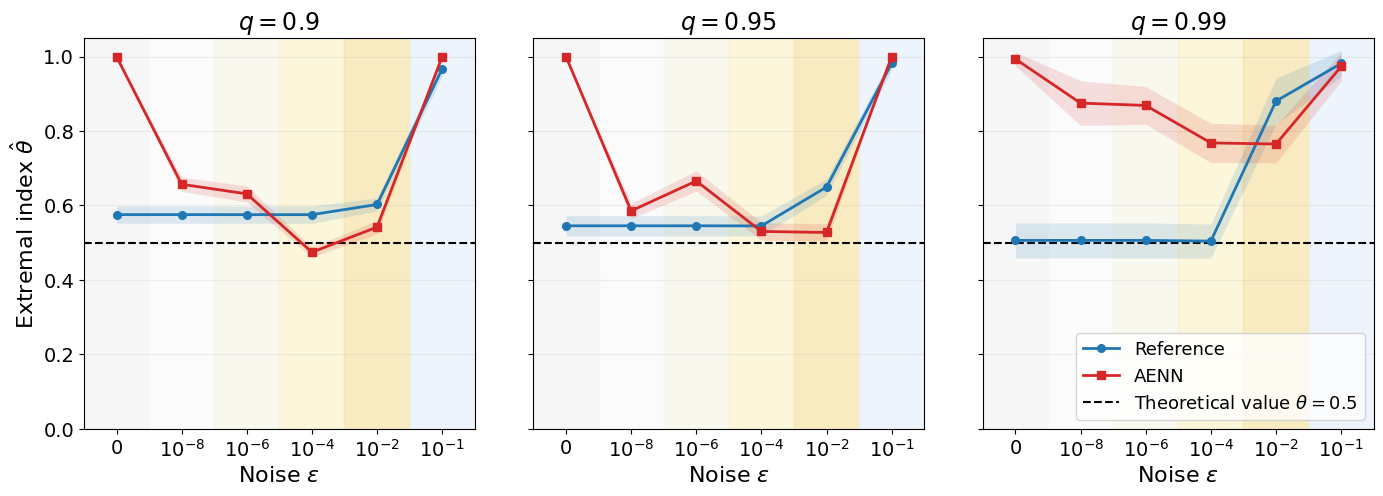

Saved: results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh/figures/shape_over_k_selected_noise.png
Saved: results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh/figures/shape_over_k_selected_noise.pdf


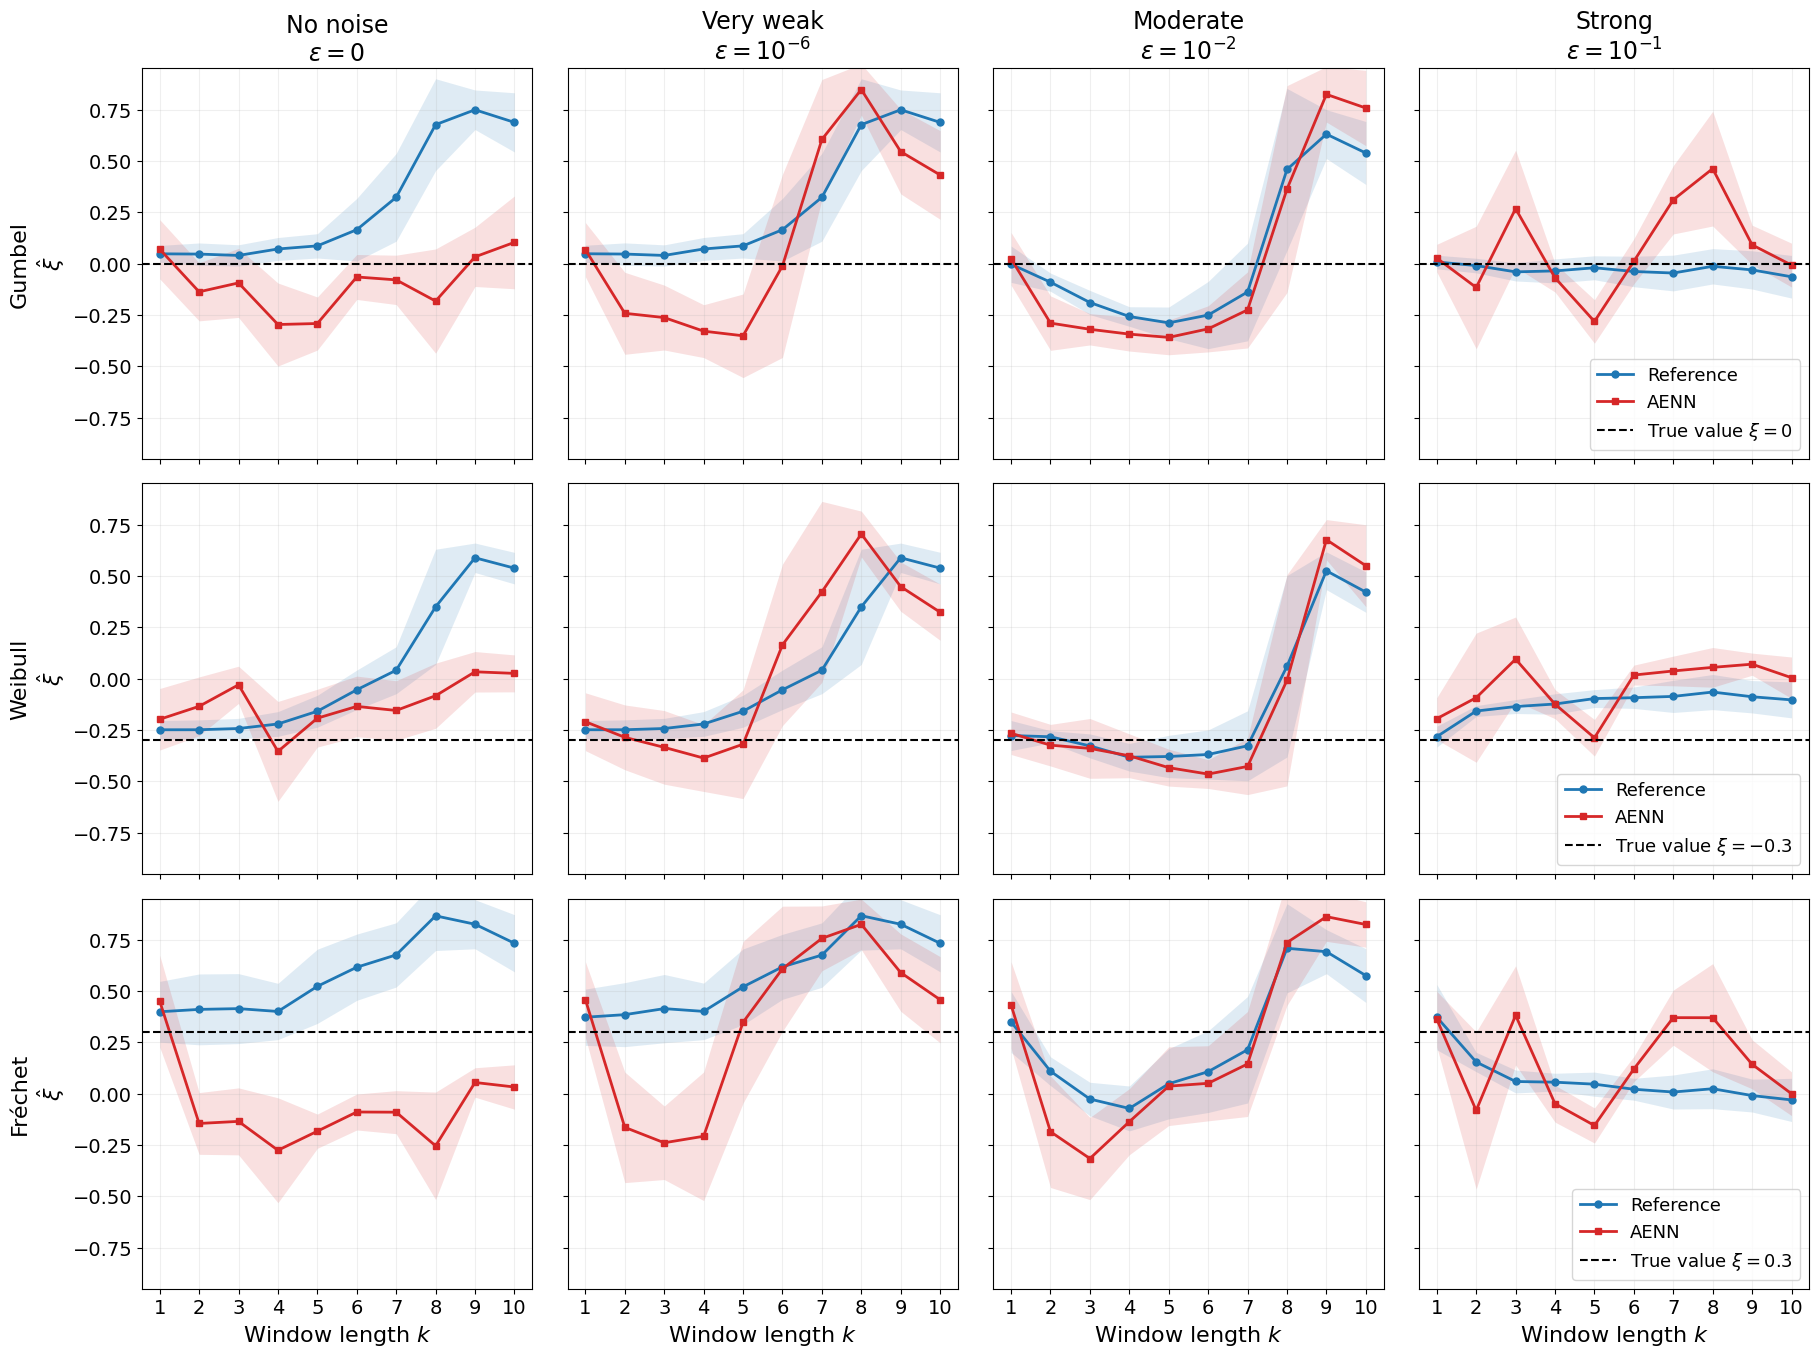

Saved: results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh/figures/return_map_density_selected_noise.png
Saved: results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh/figures/return_map_density_selected_noise.pdf


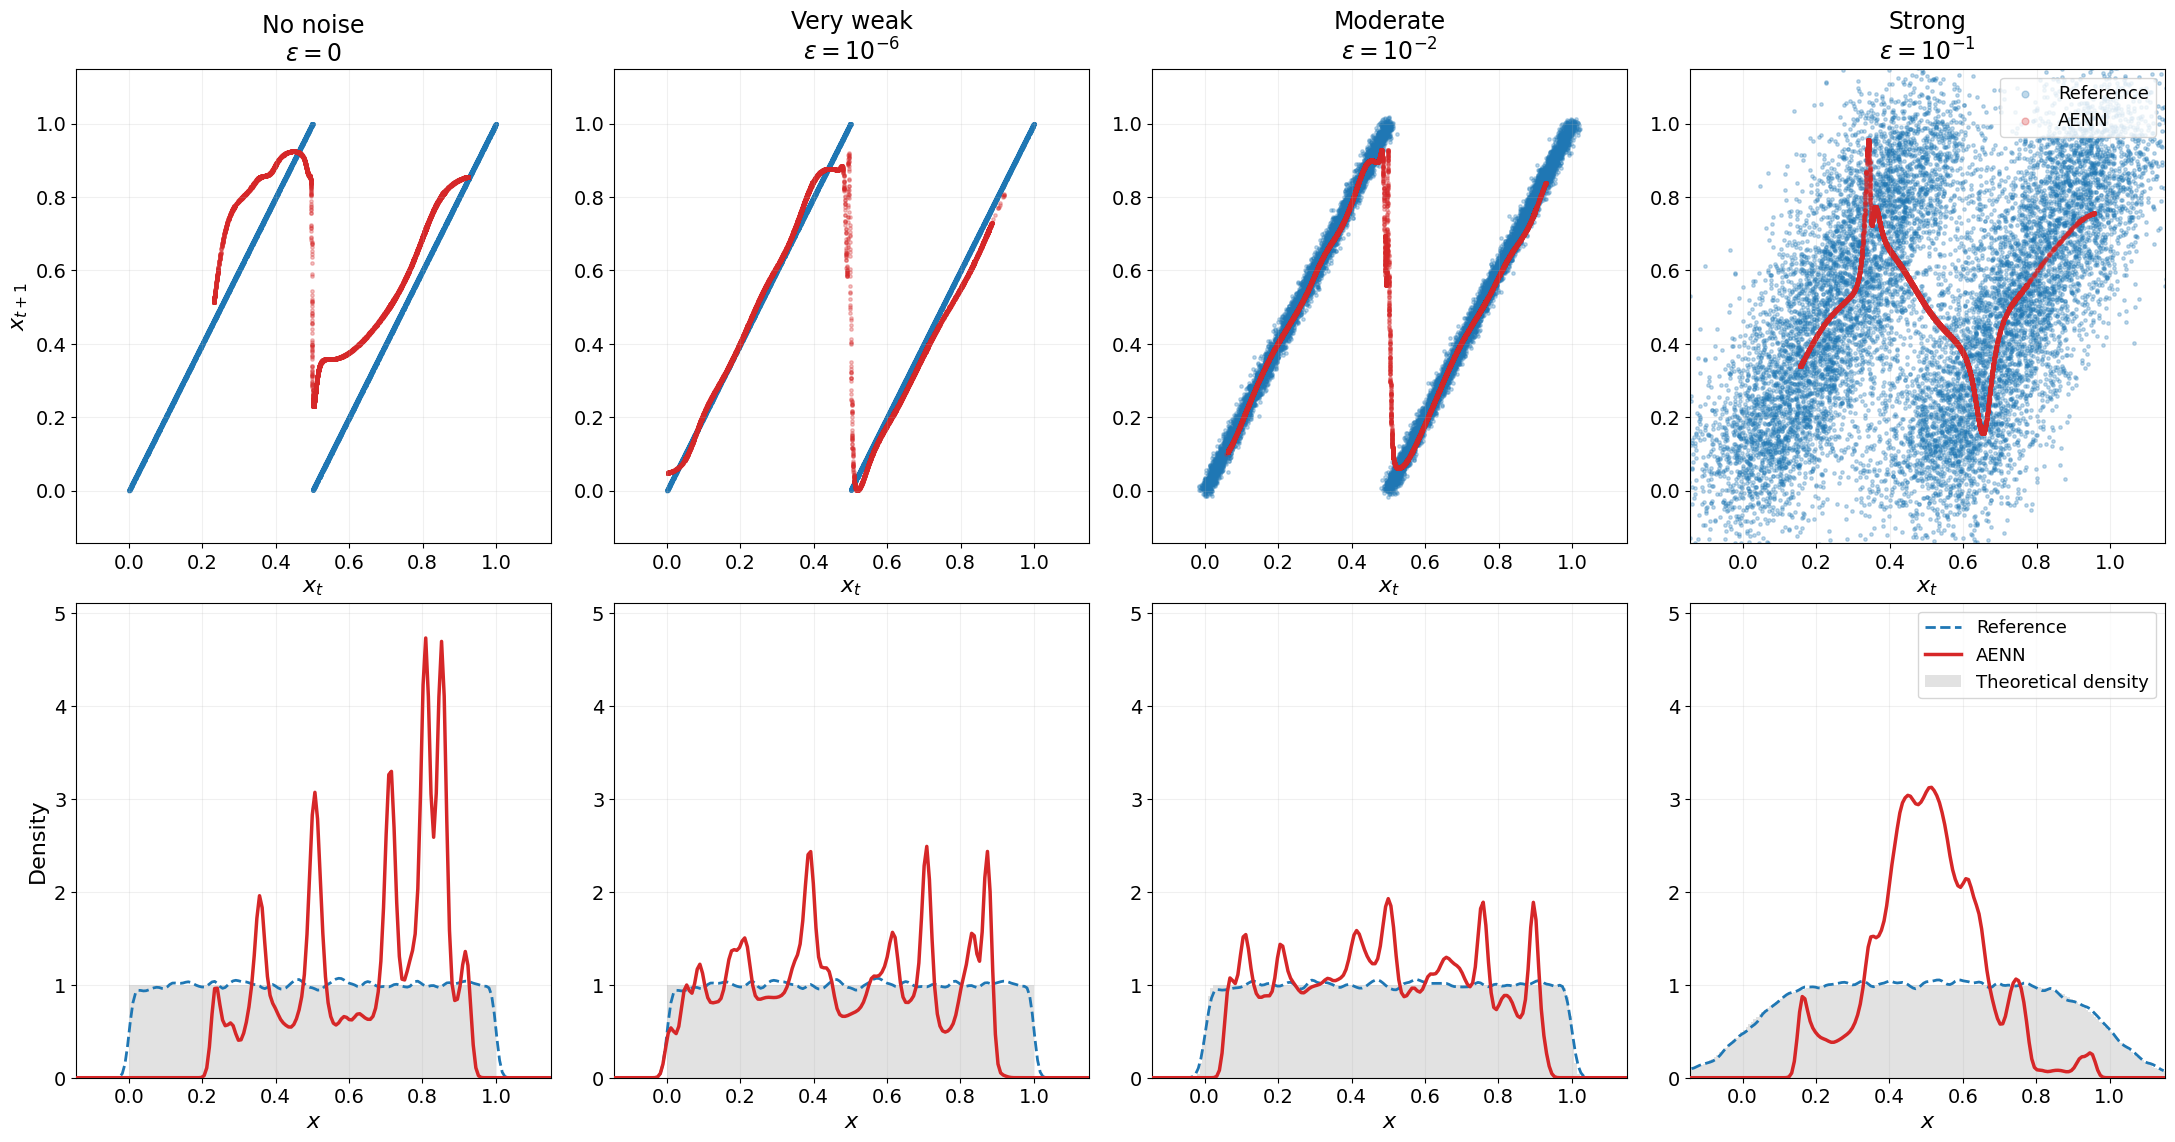

Saved: results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh/figures/istar_used_diagnostic.png
Saved: results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh/figures/istar_used_diagnostic.pdf


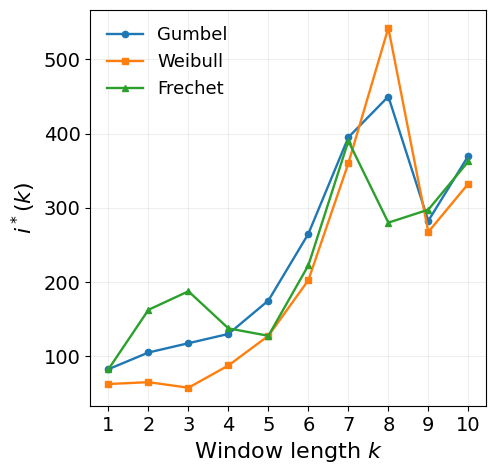


Publication outputs written to:
  Figures: results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh/figures
  Tables : results_doubling_full_fibre_istar_min0.05_paired_trajectory_tanh/tables


In [ ]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.special import ndtr
from IPython.display import display

REF_COLOR   = 'tab:blue'
AENN_COLOR  = 'tab:red'
THEORY_COLOR = 'black'
THEORY_BAR_COLOR = 'lightgray'

XI_TRUE = {
    'Gumbel':  0.0,
    'Weibull': -0.3,
    'Frechet':  0.3,
}
OBS_ORDER = ['Gumbel', 'Weibull', 'Frechet']
MODEL_ORDER = ['Reference', 'AENN']
MODEL_LABEL = {'Reference': 'Reference', 'AENN': 'AENN'}

# Main-text choices agreed in the discussion:
#   * EI plot: ALL available noise levels
#   * shape-over-k plot: selected no-noise / weak / moderate / strong levels
#   * return-map + density: the same four selected levels
SHAPE_SELECTED_NOISES = [0.0, 1e-6, 1e-2, 1e-1]
RETURN_DENSITY_SELECTED_NOISES = [0.0, 1e-6, 1e-2, 1e-1]
EI_TABLE_SELECTED_NOISES = [0.0, 1e-8, 1e-6, 1e-4, 1e-2, 1e-1]

DENSITY_BINS = 180
DENSITY_SMOOTH = 1.5
RETURN_PLOT_MAX_POINTS = 12_000
PLOT_DPI = 220

FONT_BASE   = 15
FONT_TITLE  = 17
FONT_LABEL  = 16
FONT_TICK   = 14
FONT_LEGEND = 13

plt.rcParams.update({
    'font.size': FONT_BASE,
    'axes.titlesize': FONT_TITLE,
    'axes.labelsize': FONT_LABEL,
    'xtick.labelsize': FONT_TICK,
    'ytick.labelsize': FONT_TICK,
    'legend.fontsize': FONT_LEGEND,
    'figure.titlesize': FONT_TITLE,
})

FIGDIR = os.path.join(OUT, 'figures')
TABLEDIR = os.path.join(OUT, 'tables')
os.makedirs(FIGDIR, exist_ok=True)
os.makedirs(TABLEDIR, exist_ok=True)

# ============================================================
# LOAD RESULTS
# ============================================================

gev = pd.read_csv(os.path.join(OUT, 'pertrial_gev_xi.csv'))
ei  = pd.read_csv(os.path.join(OUT, 'pertrial_ei.csv'))
blk = pd.read_csv(os.path.join(OUT, 'block_sizes_selected.csv'))

for df in (gev, ei, blk):
    df['noise'] = pd.to_numeric(df['noise'], errors='coerce')

gev['xi_true'] = gev['observable'].map(XI_TRUE)

ALL_NOISES = sorted(float(x) for x in gev['noise'].dropna().unique())
print('Available noise levels:', ALL_NOISES)

# ============================================================
# HELPERS
# ============================================================

def _noise_mask(series, target):
    """Strict noise matching; importantly 1e-8 is never confused with zero."""
    arr = pd.to_numeric(series, errors='coerce').to_numpy(dtype=float)
    target = float(target)
    if target == 0.0:
        return arr == 0.0
    return np.isclose(arr, target, rtol=1e-10, atol=0.0)


def _available_noise(target, available=None):
    """Return target if present, otherwise nearest positive-scale value."""
    if available is None:
        available = ALL_NOISES
    a = np.asarray(available, dtype=float)
    target = float(target)
    if target == 0.0:
        hit = a[a == 0.0]
        return float(hit[0]) if len(hit) else None
    hit = a[np.isclose(a, target, rtol=1e-10, atol=0.0)]
    if len(hit):
        return float(hit[0])
    pos = a[a > 0]
    if not len(pos):
        return None
    return float(pos[np.argmin(np.abs(np.log10(pos) - np.log10(target)))])


def _eps_tex(eps):
    """TeX body for epsilon value, WITHOUT surrounding $...$."""
    eps = float(eps)
    if eps == 0.0:
        return '0'
    exponent = int(np.round(np.log10(abs(eps))))
    if np.isclose(abs(eps), 10.0**exponent, rtol=1e-10, atol=0.0):
        return rf'10^{{{exponent}}}'
    return f'{eps:g}'


def _eps_label(eps, math=True):
    """Standalone epsilon tick/table label."""
    eps = float(eps)
    if eps == 0.0:
        return '0'
    exponent = int(np.round(np.log10(abs(eps))))
    if np.isclose(abs(eps), 10.0**exponent, rtol=1e-10, atol=0.0):
        return rf'$10^{{{exponent}}}$' if math else f'1e{exponent:+03d}'
    return f'{eps:g}'


def _noise_regime(eps):
    """Descriptive labels for the noise grid used in this experiment."""
    eps = float(eps)
    if eps == 0.0:
        return 'No noise'
    if eps <= 1e-8:
        return 'Negligible'
    if eps <= 1e-6:
        return 'Very weak'
    if eps <= 1e-4:
        return 'Weak'
    if eps <= 1e-2:
        return 'Moderate'
    return 'Strong'


def _fmt_mean_sd(values, digits=3):
    x = pd.to_numeric(pd.Series(values), errors='coerce').dropna().to_numpy(float)
    if x.size == 0:
        return '—', 0
    mean = float(np.mean(x))
    sd = float(np.std(x, ddof=1)) if x.size > 1 else 0.0
    return f'{mean:.{digits}f} ({sd:.{digits}f})', int(x.size)


def _save_figure(fig, stem):
    png = os.path.join(FIGDIR, stem + '.png')
    pdf = os.path.join(FIGDIR, stem + '.pdf')
    fig.savefig(png, dpi=PLOT_DPI, bbox_inches='tight')
    fig.savefig(pdf, bbox_inches='tight')
    print('Saved:', png)
    print('Saved:', pdf)


def _make_axes_square(axarr):
    """Force every subplot box to be square and keep ticks easy to read."""
    for ax in np.asarray(axarr, dtype=object).ravel():
        try:
            ax.set_box_aspect(1)
        except Exception:
            pass
        ax.tick_params(axis='both', which='major', labelsize=FONT_TICK)


def _mean_sd_by_k(h, model, ks):
    means, sds = [], []
    for k in ks:
        x = pd.to_numeric(
            h[(h['model'] == model) & (h['k'] == k)]['xi'],
            errors='coerce'
        ).dropna().to_numpy(float)
        means.append(np.mean(x) if len(x) else np.nan)
        sds.append(np.std(x, ddof=1) if len(x) > 1 else (0.0 if len(x) == 1 else np.nan))
    return np.asarray(means, float), np.asarray(sds, float)


def _finite_1d(x):
    x = np.asarray(x, dtype=float).reshape(-1)
    return x[np.isfinite(x)]


def _density_curve(x, edges):
    x = _finite_1d(x)
    centres = 0.5 * (edges[:-1] + edges[1:])
    if x.size == 0:
        return centres, np.full_like(centres, np.nan, dtype=float)
    h, e = np.histogram(x, bins=edges, density=True)
    if DENSITY_SMOOTH > 0:
        h = gaussian_filter1d(h.astype(float), sigma=DENSITY_SMOOTH)
        dx = e[1] - e[0]
        area = np.sum(h) * dx
        if np.isfinite(area) and area > 0:
            h = h / area
    return 0.5 * (e[:-1] + e[1:]), h


def _theoretical_doubling_density(x, eps):
    """Observed-state density for clean Doubling + observational N(0,eps^2) noise."""
    x = np.asarray(x, dtype=float)
    eps = float(eps)
    if eps == 0.0:
        return ((x >= 0.0) & (x <= 1.0)).astype(float)
    return ndtr(x / eps) - ndtr((x - 1.0) / eps)


def _return_pairs(x, max_points=RETURN_PLOT_MAX_POINTS):
    a = _finite_1d(x)
    if a.size < 2:
        return np.empty(0), np.empty(0)
    x0, x1 = a[:-1], a[1:]
    ok = np.isfinite(x0) & np.isfinite(x1)
    x0, x1 = x0[ok], x1[ok]
    if max_points and x0.size > max_points:
        idx = np.linspace(0, x0.size - 1, int(max_points), dtype=int)
        x0, x1 = x0[idx], x1[idx]
    return x0, x1


# ============================================================
# A. NUMERICAL SUMMARY FILES
# ============================================================

xi_numeric = (
    gev.groupby(['map', 'observable', 'k', 'noise', 'model'])['xi']
       .agg(n='count', mean='mean', sd='std')
       .reset_index()
)
xi_numeric['xi_true'] = xi_numeric['observable'].map(XI_TRUE)
xi_numeric['bias'] = xi_numeric['mean'] - xi_numeric['xi_true']
xi_numeric.to_csv(os.path.join(OUT, 'summary_xi_istar.csv'), index=False)

istar_used = (
    blk.groupby(['map', 'observable', 'k'])['i_star']
       .agg(['median', 'min', 'max'])
       .reset_index()
)
istar_used.to_csv(os.path.join(OUT, 'summary_istar_used.csv'), index=False)

# ============================================================
# B. TABLE: GEV SHAPE AT k=1 ACROSS ALL NOISE LEVELS
# ============================================================

shape_rows = []
shape_n_rows = []
for eps in ALL_NOISES:
    row = {'Noise epsilon': _eps_label(eps, math=False), 'Regime': _noise_regime(eps)}
    nrow = {'Noise epsilon': _eps_label(eps, math=False)}
    for ob in OBS_ORDER:
        for mdl in MODEL_ORDER:
            vals = gev[
                (gev['k'] == 1)
                & (gev['observable'] == ob)
                & (gev['model'] == mdl)
                & _noise_mask(gev['noise'], eps)
            ]['xi']
            txt, n = _fmt_mean_sd(vals)
            col = f'{ob} | {MODEL_LABEL[mdl]}'
            row[col] = txt
            nrow[col] = n
    shape_rows.append(row)
    shape_n_rows.append(nrow)

shape_k1_table = pd.DataFrame(shape_rows)
shape_k1_n = pd.DataFrame(shape_n_rows)
shape_k1_table.to_csv(os.path.join(TABLEDIR, 'table_shape_k1_all_noise_mean_sd.csv'), index=False)
shape_k1_n.to_csv(os.path.join(TABLEDIR, 'table_shape_k1_all_noise_valid_n.csv'), index=False)

with open(os.path.join(TABLEDIR, 'table_shape_k1_all_noise_mean_sd.tex'), 'w') as f:
    f.write(shape_k1_table.to_latex(index=False, escape=False))

print('\nGEV shape at k=1 across all noise levels: mean (SD)')
display(shape_k1_table)

# ============================================================
# C. TABLES: EXTREMAL INDEX
#    - full all-noise table saved for completeness
#    - selected main-text table follows the agreed compact layout
# ============================================================

# EI threshold quantiles to show in tables and figures.

EI_QLEVELS_TO_PLOT = [0.90, 0.95, 0.99]

available_q = sorted(float(q) for q in ei['q'].dropna().unique())
Q_ORDER = [
    q for q in EI_QLEVELS_TO_PLOT
    if np.any(np.isclose(np.asarray(available_q, float), q, rtol=0, atol=1e-12))
]

if not Q_ORDER:
    # Safety fallback: if the requested levels are absent, use all levels in the CSV.
    Q_ORDER = available_q

missing_q = [
    q for q in EI_QLEVELS_TO_PLOT
    if not np.any(np.isclose(np.asarray(available_q, float), q, rtol=0, atol=1e-12))
]
print('EI thresholds available in CSV:', available_q)
print('EI thresholds used for table/plot:', Q_ORDER)
if missing_q:
    print('WARNING: requested EI thresholds not found:', missing_q)


def _build_ei_table(noises):
    rows, nrows = [], []
    for eps0 in noises:
        eps = _available_noise(eps0, sorted(ei['noise'].dropna().unique()))
        if eps is None:
            continue
        row = {'Noise epsilon': _eps_label(eps, math=False), 'Regime': _noise_regime(eps)}
        nrow = {'Noise epsilon': _eps_label(eps, math=False)}
        for q in Q_ORDER:
            for mdl in MODEL_ORDER:
                vals = ei[
                    np.isclose(ei['q'].to_numpy(float), float(q), rtol=0, atol=1e-12)
                    & (ei['model'] == mdl).to_numpy()
                    & _noise_mask(ei['noise'], eps)
                ]['ei']
                txt, n = _fmt_mean_sd(vals)
                col = f'q={q:g} | {MODEL_LABEL[mdl]}'
                row[col] = txt
                nrow[col] = n
        rows.append(row)
        nrows.append(nrow)
    return pd.DataFrame(rows), pd.DataFrame(nrows)


ei_table_all, ei_n_all = _build_ei_table(sorted(ei['noise'].dropna().unique()))
ei_table_main, ei_n_main = _build_ei_table(EI_TABLE_SELECTED_NOISES)

ei_table_all.to_csv(os.path.join(TABLEDIR, 'table_ei_all_noise_mean_sd.csv'), index=False)
ei_n_all.to_csv(os.path.join(TABLEDIR, 'table_ei_all_noise_valid_n.csv'), index=False)
ei_table_main.to_csv(os.path.join(TABLEDIR, 'table_ei_selected_noise_mean_sd.csv'), index=False)
ei_n_main.to_csv(os.path.join(TABLEDIR, 'table_ei_selected_noise_valid_n.csv'), index=False)

with open(os.path.join(TABLEDIR, 'table_ei_selected_noise_mean_sd.tex'), 'w') as f:
    f.write(ei_table_main.to_latex(index=False, escape=False))

print('\nExtremal index selected-noise manuscript table: mean (SD)')
display(ei_table_main)

# warn if finite-only summaries contain fewer than the requested number of trials
for name, nt in [('shape k=1', shape_k1_n), ('EI selected', ei_n_main)]:
    numeric = nt.drop(columns=['Noise epsilon'], errors='ignore').apply(pd.to_numeric, errors='coerce')
    if numeric.size and np.nanmin(numeric.to_numpy(float)) < TRIALS:
        print(f'NOTE: {name} contains cells with fewer than {TRIALS} finite estimates. '
              'See the corresponding *_valid_n.csv file.')

# ============================================================
# D. FIGURE 1: EXTREMAL INDEX ACROSS ALL NOISE LEVELS
# ============================================================

EI_NOISES = sorted(float(x) for x in ei['noise'].dropna().unique())
xpos = np.arange(len(EI_NOISES), dtype=float)

fig, axes = plt.subplots(1, len(Q_ORDER), figsize=(4.8 * len(Q_ORDER), 4.8),
                         sharex=True, sharey=True, squeeze=False)
axes = axes[0]
_make_axes_square(axes)


regime_spans = []
for reg in ['No noise', 'Negligible', 'Very weak', 'Weak', 'Moderate', 'Strong']:
    ids = [i for i, eps in enumerate(EI_NOISES) if _noise_regime(eps) == reg]
    if ids:
        regime_spans.append((reg, min(ids) - 0.5, max(ids) + 0.5))
regime_face = {
    'No noise': '#f4f4f4',
    'Negligible': '#fafafa',
    'Very weak': '#f8f6ea',
    'Weak': '#fbf3cf',
    'Moderate': '#f8e5ac',
    'Strong': '#e8f1fa',
}

for j, q in enumerate(Q_ORDER):
    ax = axes[j]
    for reg, left, right in regime_spans:
        ax.axvspan(left, right, color=regime_face[reg], alpha=0.75, zorder=0)

    for mdl, col, marker in [('Reference', REF_COLOR, 'o'), ('AENN', AENN_COLOR, 's')]:
        means, sds = [], []
        for eps in EI_NOISES:
            v = pd.to_numeric(
                ei[
                    np.isclose(ei['q'].to_numpy(float), float(q), rtol=0, atol=1e-12)
                    & (ei['model'] == mdl).to_numpy()
                    & _noise_mask(ei['noise'], eps)
                ]['ei'],
                errors='coerce'
            ).dropna().to_numpy(float)
            means.append(np.mean(v) if len(v) else np.nan)
            sds.append(np.std(v, ddof=1) if len(v) > 1 else (0.0 if len(v) == 1 else np.nan))
        means = np.asarray(means, float)
        sds = np.asarray(sds, float)
        ax.plot(xpos, means, marker=marker, ms=5.5, lw=2.0, color=col,
                label=MODEL_LABEL[mdl], zorder=3)
        ax.fill_between(xpos, means - sds, means + sds, color=col, alpha=0.14, linewidth=0, zorder=2)

    ax.axhline(0.5, color=THEORY_COLOR, ls='--', lw=1.5,
               label=r'Theoretical value $\theta=0.5$', zorder=1)
    ax.set_title(rf'$q={q:g}$', fontsize=FONT_TITLE)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlim(-0.5, len(EI_NOISES) - 0.5)
    ax.set_xticks(xpos)
    ax.set_xticklabels([_eps_label(eps) for eps in EI_NOISES], rotation=0)
    ax.set_xlabel(r'Noise $\epsilon$')
    ax.grid(alpha=0.20, axis='y')
    if j == 0:
        ax.set_ylabel(r'Extremal index $\hat\theta$')

# one legend, in the right subplot at the bottom-right
handles, labels = axes[-1].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axes[-1].legend(uniq.values(), uniq.keys(), loc='lower right', fontsize=FONT_LEGEND, frameon=True)

fig.tight_layout()
_save_figure(fig, 'ei_all_noise_all_thresholds')
plt.show()

# ============================================================
# E. FIGURE 2: GEV SHAPE OVER k AT SELECTED NOISE LEVELS
#    Columns: no noise / weak / moderate / strong
#    Rows: Gumbel / Weibull / Frechet
# ============================================================

shape_noises = []
for eps0 in SHAPE_SELECTED_NOISES:
    eps = _available_noise(eps0, ALL_NOISES)
    if eps is not None and eps not in shape_noises:
        shape_noises.append(eps)

fig, axes = plt.subplots(
    len(OBS_ORDER), len(shape_noises),
    figsize=(4.6 * len(shape_noises), 4.6 * len(OBS_ORDER)),
    sharex=True, sharey=True, squeeze=False
)
_make_axes_square(axes)

for i, ob in enumerate(OBS_ORDER):
    for j, eps in enumerate(shape_noises):
        ax = axes[i, j]
        h = gev[(gev['observable'] == ob) & _noise_mask(gev['noise'], eps)]
        ks = sorted(int(k) for k in h['k'].dropna().unique())

        for mdl, col, marker in [('Reference', REF_COLOR, 'o'), ('AENN', AENN_COLOR, 's')]:
            m, sd = _mean_sd_by_k(h, mdl, ks)
            kk = np.asarray(ks, float)
            ax.plot(
                kk, m,
                marker=marker, ms=5.0, lw=2.0, color=col,
                label=MODEL_LABEL[mdl]
            )
            ax.fill_between(
                kk, m - sd, m + sd,
                color=col, alpha=0.14, linewidth=0
            )

        ax.axhline(
            XI_TRUE[ob],
            color=THEORY_COLOR, ls='--', lw=1.5,
            label=rf'True value $\xi={XI_TRUE[ob]:g}$'
        )

        ax.set_ylim(-0.95, 0.95)
        ax.set_xticks(ks)
        ax.grid(alpha=0.20)

        if i == 0:
            ax.set_title(
                _noise_regime(eps) + '\n' + rf'$\epsilon={_eps_tex(eps)}$',
                fontsize=FONT_TITLE
            )

        if j == 0:
            pretty = 'Fréchet' if ob == 'Frechet' else ob
            ax.set_ylabel(pretty + '\n' + r'$\hat\xi$', fontsize=FONT_LABEL)

        if i == len(OBS_ORDER) - 1:
            ax.set_xlabel(r'Window length $k$')

    # One legend at the right of each observable row so the correct
    # true xi value is explicitly stated for Gumbel/Weibull/Frechet.
    handles, labels = axes[i, -1].get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    axes[i, -1].legend(
        uniq.values(), uniq.keys(),
        loc='lower right', fontsize=FONT_LEGEND, frameon=True
    )

fig.tight_layout()
_save_figure(fig, 'shape_over_k_selected_noise')
plt.show()

# ============================================================
# F. FIGURE 3: RETURN MAP + DENSITY AT SELECTED NOISE LEVELS
# ============================================================

RETURN_DIR = os.path.join(OUT, 'return_maps')
return_files = sorted(glob.glob(os.path.join(RETURN_DIR, 'return_map_data_*.npz')))

return_cases = []
for fn in return_files:
    try:
        z = np.load(fn, allow_pickle=False)
        eps = float(np.asarray(z['noise']).reshape(-1)[0]) if 'noise' in z.files else np.nan
        trial = int(np.asarray(z['trial']).reshape(-1)[0]) if 'trial' in z.files else RETURN_MAP_TRIAL
        mp = str(np.asarray(z['map']).reshape(-1)[0]) if 'map' in z.files else 'Doubling'
        return_cases.append({
            'file': fn,
            'eps': eps,
            'trial': trial,
            'map': mp,
            'reference': _finite_1d(z['reference']),
            'aenn': _finite_1d(z['aenn']),
        })
    except Exception as exc:
        print('Skipping unreadable return-map file:', fn, exc)

selected_cases = []
available_return_noises = sorted({float(c['eps']) for c in return_cases if np.isfinite(c['eps'])})
for eps0 in RETURN_DENSITY_SELECTED_NOISES:
    eps = _available_noise(eps0, available_return_noises)
    if eps is None:
        continue
    matches = [c for c in return_cases if _noise_mask(pd.Series([c['eps']]), eps)[0]]
    # Prefer the configured representative return-map trial.
    trial_matches = [c for c in matches if c['trial'] == RETURN_MAP_TRIAL]
    c = trial_matches[0] if trial_matches else (matches[0] if matches else None)
    if c is not None:
        selected_cases.append(c)

if selected_cases:
    # --------------------------------------------------------
    # Common return-map axis range across selected cases
    # --------------------------------------------------------
    rv = []
    for c in selected_cases:
        r0, r1 = _return_pairs(c['reference'])
        a0, a1 = _return_pairs(c['aenn'])
        if len(r0):
            rv.extend([r0, r1])
        if len(a0):
            rv.extend([a0, a1])

    rv = np.concatenate(rv) if rv else np.array([0.0, 1.0])
    qlo, qhi = np.nanquantile(rv, [0.001, 0.999])
    rlo, rhi = min(float(qlo), 0.0), max(float(qhi), 1.0)
    rpad = 0.035 * max(rhi - rlo, 1e-8)
    rlo, rhi = rlo - rpad, rhi + rpad

    # --------------------------------------------------------
    # Common density x-range AND y-range across selected cases
    # --------------------------------------------------------
    dv = []
    for c in selected_cases:
        if c['reference'].size:
            dv.append(c['reference'])
        if c['aenn'].size:
            dv.append(c['aenn'])
    dv = np.concatenate(dv) if dv else np.array([0.0, 1.0])

    qlo, qhi = np.nanquantile(dv, [0.001, 0.999])
    dlo, dhi = min(float(qlo), 0.0), max(float(qhi), 1.0)
    dpad = 0.035 * max(dhi - dlo, 1e-8)
    dlo, dhi = dlo - dpad, dhi + dpad
    density_edges = np.linspace(dlo, dhi, DENSITY_BINS + 1)

    prepared_density = []
    density_ymax = 0.0
    for c in selected_cases:
        xr, dr = _density_curve(c['reference'], density_edges)
        xa, da = _density_curve(c['aenn'], density_edges)
        dt = _theoretical_doubling_density(xr, c['eps'])
        prepared_density.append((xr, dr, xa, da, dt))

        finite_y = np.concatenate([
            dr[np.isfinite(dr)],
            da[np.isfinite(da)],
            dt[np.isfinite(dt)]
        ])
        if finite_y.size:
            density_ymax = max(density_ymax, float(np.max(finite_y)))

    density_ymax = 1.08 * density_ymax if density_ymax > 0 else 1.0

    # --------------------------------------------------------
    # 2 x 4 publication layout
    # --------------------------------------------------------
    fig, axes = plt.subplots(
        2, len(selected_cases),
        figsize=(22.0, 11.5),
        squeeze=False
    )
    _make_axes_square(axes)

    for j, (c, dens) in enumerate(zip(selected_cases, prepared_density)):
        eps = c['eps']
        ref = c['reference']
        aen = c['aenn']
        xr, dr, xa, da, dt = dens

        # ---- top: return map
        ax = axes[0, j]
        r0, r1 = _return_pairs(ref)
        a0, a1 = _return_pairs(aen)

        ax.scatter(
            r0, r1,
            s=6, alpha=0.28, color=REF_COLOR,
            label='Reference', rasterized=True
        )
        ax.scatter(
            a0, a1,
            s=6, alpha=0.28, color=AENN_COLOR,
            label='AENN', rasterized=True
        )

        ax.set_xlim(rlo, rhi)
        ax.set_ylim(rlo, rhi)
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(
            _noise_regime(eps) + '\n' + rf'$\epsilon={_eps_tex(eps)}$',
            fontsize=FONT_TITLE
        )
        ax.set_xlabel(r'$x_t$')
        if j == 0:
            ax.set_ylabel(r'$x_{t+1}$')
        ax.grid(alpha=0.18)
        ax.tick_params(axis='both', labelsize=FONT_TICK)

        # ---- bottom: theoretical bars + Reference dashed + AENN solid
        ax = axes[1, j]
        width = (xr[1] - xr[0]) if len(xr) > 1 else 0.01

        if np.any(np.isfinite(dt)):
            ax.bar(
                xr, dt,
                width=width,
                color=THEORY_BAR_COLOR,
                alpha=0.65,
                edgecolor='none',
                align='center',
                label='Theoretical density',
                zorder=1
            )

        ax.plot(
            xr, dr,
            color=REF_COLOR,
            lw=2.0,
            ls='--',
            label='Reference',
            zorder=3
        )
        ax.plot(
            xa, da,
            color=AENN_COLOR,
            lw=2.5,
            ls='-',
            label='AENN',
            zorder=4
        )

        ax.set_xlim(dlo, dhi)
        ax.set_ylim(0, density_ymax)
        ax.set_xlabel(r'$x$')
        if j == 0:
            ax.set_ylabel('Density')
        ax.grid(alpha=0.18)
        ax.tick_params(axis='both', labelsize=FONT_TICK)

    # Legend boxes only in the top-right subplots of each row.
    axes[0, -1].legend(
        loc='upper right', fontsize=FONT_LEGEND, frameon=True, markerscale=2.0
    )
    axes[1, -1].legend(
        loc='upper right', fontsize=FONT_LEGEND, frameon=True
    )

    fig.tight_layout()
    _save_figure(fig, 'return_map_density_selected_noise')
    plt.show()
else:
    print('No return_map_data_*.npz files found; skipping return-map/density figure.')

# ============================================================
# G. OPTIONAL DIAGNOSTIC: BLOCK LENGTHS ACTUALLY USED
# ============================================================

fig, ax = plt.subplots(figsize=(5.2, 5.2))
_make_axes_square([ax])
for ob, col, marker in [('Gumbel', REF_COLOR, 'o'), ('Weibull', 'tab:orange', 's'),
                        ('Frechet', 'tab:green', '^')]:
    h = blk[blk['observable'] == ob]
    if len(h):
        m = h.groupby('k')['i_star'].median()
        ax.plot(m.index, m.values, marker=marker, lw=1.7, ms=4.5, color=col, label=ob)
ax.set_xlabel(r'Window length $k$')
ax.set_ylabel(r'$i^*(k)$')
ax.set_xticks(sorted(int(k) for k in blk['k'].dropna().unique()))
ax.grid(alpha=0.20)
ax.legend(frameon=False, fontsize=FONT_LEGEND)
ax.tick_params(axis='both', labelsize=FONT_TICK)
try:
    ax.set_box_aspect(1)
except Exception:
    pass
fig.tight_layout()
_save_figure(fig, 'istar_used_diagnostic')
plt.show()

print('\nPublication outputs written to:')
print('  Figures:', FIGDIR)
print('  Tables :', TABLEDIR)